<a href="https://colab.research.google.com/github/kitlapp/Data_Viz/blob/main/visualization_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**All visualization graphs and their beautification, including aligned titles, colors and using multiple graphs output, were created using guidance from Gemini. Also Gemini assisted in managing the initial dataframe to create inputs for Kmeans and Linear Regression Algorithms.**

# The Dataset acquisition

The analysis utilizes the 2019 Hospital Inpatient Discharges (SPARCS De-Identified) dataset, publicly available through the New York State Open Data Portal (https://health.data.ny.gov/Health/Hospital-Inpatient-Discharges-SPARCS-De-Identified/4ny4-j5zv).  

SPARCS (Statewide Planning and Research Cooperative System) is a comprehensive administrative database that captures patient-level inpatient discharge records across New York State. The dataset includes clinical, operational, and financial variables such as length of stay (LOS), total charges, payer type, severity of illness, risk of mortality, and facility identifiers.

The dataset was restricted to discharges occurring in calendar year 2019 to avoid analysis inconsistencies arising from COVID-19 pandemic. Additionally it was narrowd to 3 Hospitals  Furthermore, the scope of the study was narrowed to  allow comparisons cross - facilities but also to maintain computational efficiency within the PowerBI environment. Two of the hospitals are major institutions in NYC while the third is more regional with a possibility of different LOS patterns and a different cost structure

With this filtering we are hoping for a more standardized performance comparison using normalized key performance indicators (KPIs), such as average LOS and average charges per discharge, independent of hospital size.

- Maimonides Medical Center : Large Establishment in NYC
- NewYork-Presbyterian / Hudson Valley Hospital : Strong comparison to Maimonidies
- St. Joseph's Medical Center : Regional LOS and cost structure
#  
Each row in the dataset does not represent one patient but rather one discharge. So, we are analyzing discharges and this could occur to the same patient.  
#
Differences in discharge volume across hospitals were addressed using normalized performance metrics to ensure comparability.

# Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import drive
#
# Regression Analysis
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# The specific import for Trend Projection (if using stats)
#from scipy.stats import linregress
#
# Set pandas display option to show up to 100 columns when printing a DataFrame
pd.set_option('display.max_columns', 100)


In [ ]:
#df.columns

# Explanation of Data Fields

**Hospital County**
Type is Char. Length is 11.*** A description of the county ***in which the hospital is located. Blank for records with enhanced de-identification.  
#  
**Facility Name**
Type is Char. Length is 112.*** The name of the facility where services were performed*** based on the Permanent Facility Identifier (PFI), as maintained by the NYSDOH Division of Health Facility Planning. For records with enhanced de-identification, ‘Redacted for Confidentiality’ appears.  

**Age Group**
Type is Char. Length is 11.*** Age in years at time of discharge.*** Grouped into the following age groups: 0 to 17, 18 to 29, 30 to 49, 50 to 69, and 70 or Older  

**Gender**
Type is Char. Length is 1. ***Patient gender: (M) Male, (F) Female, (U) Unknown***.  

**Race**
Type is Char. Length is 32.*** Patient race***. Black/African American, Multi-racial, Other Race, White. Other Race includes Native Americans and Asian/Pacific Islander.  

**Ethnicity**
Type is Char. Length is 20. ***Patient ethnicity.*** The ethnicity of the patient: Spanish/Hispanic Origin, Not of Spanish/Hispanic Origin, Multi-ethnic Unknown.  

**Length of Stay**
Type is Char. Length is 5. ***The total number of patient days ***at an acute level and/or other than acute care level (excluding leave of absence days) (Discharge Date - Admission Date) + 1. Length of Stay greater than or equal to 120 days has been aggregated to 120+ days  

**Type of Admission**
Type is Char. Length is 15. A description of the ***manner in which the patient was admitted to the health care facility***: Elective, Emergency, Newborn, Not Available, Trauma, Urgent   

**Patient Disposition**
Type is Char. Length is 37. ***The patient's destination or status upon discharge***  

**APR DRG Description ??**
Type is Char. Length is 500. The*** APR-DRG Classification Code Description*** in Calendar Year 2019, Version 36 of the APR- DRG Grouper. http://www.health.ny.gov/statistics/sparcs/sysdoc/appy.htm  
#
**APR Severity of Illness Description**
Type is Char. Length is 8. All Patient Refined*** Severity of Illness ***(APR SOI) Description: Undetermined (0), Minor (1), Moderate (2), Major (3), Extreme (4)  

**APR Risk of Mortality**
Type is Char. Length is 8. All Patient ***Refined Risk of Mortality*** (APR ROM) Description: Undetermined (0), Minor (1), Moderate (2), Major (3), Extreme (4).  
#
**Payment Typology 1**
Type is Char. Length is 25. A description ***of the type of payment ***for this occurrence.  

**Emergency Department Indicator**
Type is Char. Length is 1. The Emergency Department Indicator is set based on the submitted revenue codes.*** If the record contained an Emergency Department*** revenue code of 045X, the indicator is set to "Y", otherwise it will be “N”.  

**Total Charges**
Type is Char. Length is 8. ***Total charges*** for the discharge.  
#
**Total Costs**
Type is Char. Length is 8. ***Total estimated cost*** for the discharge.


# Column Selection

We excluded deep medical analysis with CCSR terms
All ids that might be confusing.  
Discharge year as our dataset is related only to 2019  
#
We selected the following features according to business logic:
#

**Identification**  
Hospital County  
Facility Name  

**Demographics**  
Age Group  
Gender  
Race / Ethnicity (only if you want social analysis — otherwise skip)    
  
**OPERATIONS**  
Length of Stay (IMPORTANT → convert to numeric)  
Type of Admission  
Emergency Department Indicator  
'Patient Disposition'
  
**FINANCIAL**  
Total Charges (convert to numeric)  
Total Costs (convert to numeric)  

**CLINICAL COMPLEXITY**  
APR Severity of Illness Description (SOI)

APR Risk of Mortality (ROM)

APR DRG Description      

**PAYER**

Payment Typology 1 (KEEP ONLY THIS)


# **About Low Variance Features**

# Read Raw GitHub Datasets

In [ ]:
df2019 = pd.read_csv('https://raw.githubusercontent.com/kitlapp/Data_Viz/refs/heads/main/raw_hospital_discharges_2019.csv', low_memory = False)
df2018= pd.read_csv('https://raw.githubusercontent.com/kitlapp/Data_Viz/refs/heads/main/raw_hospital_discharges_2018.csv', low_memory = False)

In [ ]:
print("Number of Rows: 2018-->", df2018.shape[0])
print("Number of Columns: 2018-->", df2018.shape[1])
print("Number of Rows: 2019-->", df2019.shape[0])
print("Number of Columns: 2019-->", df2019.shape[1])

Number of Rows: 2018--> 54312
Number of Columns: 2018--> 33
Number of Rows: 2019--> 53390
Number of Columns: 2019--> 33


In [ ]:
#Concatenate Vertically the 2 dataframes
df = pd.concat([df2018, df2019], ignore_index=True)

In [ ]:
#Sanity Check
print("Number of Rows:-->", df.shape[0])
print("Number of Columns: -->", df.shape[1])

Number of Rows:--> 107702
Number of Columns: --> 33


# Retrospective Duplication Test

In [ ]:
# Keep will
dup_groups = df[df.duplicated(keep=False)]
n_groups = dup_groups.groupby(list(df.columns)).ngroups
n_groups

189

In [ ]:
dups_all = df.duplicated(keep=False)
df_dups_all = df[dups_all].sort_values(by=df.columns.tolist())
df_dups_all.shape[0]

2228

# 1st - Initial Identification of the dataframe.  


In [ ]:
df.head()

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,Discharge Year,CCSR Diagnosis Code,CCSR Diagnosis Description,CCSR Procedure Code,CCSR Procedure Description,APR DRG Code,APR DRG Description,APR MDC Code,APR MDC Description,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Kings,7001020,1305,Maimonides Medical Center,0 to 17,112,F,Other Race,Not Span/Hispanic,1,Emergency,Home or Self Care,2018,RSP002,PNEUMONIA (EXCEPT THAT CAUSED BY TUBERCULOSIS),ADM017,ADMINISTRATION OF NUTRITIONAL AND ELECTROLYTIC...,139.0,OTHER PNEUMONIA,4.0,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,2.0,Moderate,Minor,Medical,Medicaid,Medicaid,Self-Pay,NaN,False,"$7,983","$3,447.96"
1,New York City,Kings,7001020,1305,Maimonides Medical Center,70 or Older,112,M,Other Race,Not Span/Hispanic,4,Emergency,Home or Self Care,2018,GEN013,INFLAMMATORY CONDITIONS OF MALE GENITAL ORGANS,ADM015,ADMINISTRATION OF ANTIBIOTICS,501.0,MALE REPRODUCTIVE SYSTEM DIAGNOSES EXCEPT MALI...,12.0,DISEASES AND DISORDERS OF THE MALE REPRODUCTIV...,3.0,Major,Major,Medical,Medicare,Medicaid,Self-Pay,NaN,False,"$23,752.02","$6,475.87"
2,New York City,Kings,7001020,1305,Maimonides Medical Center,0 to 17,112,M,Other Race,Not Span/Hispanic,15,Newborn,Home or Self Care,2018,PNL001,LIVEBORN,ESA004,NON-INVASIVE VENTILATION,614.0,NEONATE BWT 1500-1999G W OR W/O OTHER SIGNIFIC...,15.0,NEWBORNS AND OTHER NEONATES WITH CONDITIONS OR...,2.0,Moderate,Minor,Medical,Private Health Insurance,Self-Pay,NaN,01700,False,"$175,527.01","$24,953.85"
3,New York City,Kings,7001020,1305,Maimonides Medical Center,0 to 17,112,M,White,Not Span/Hispanic,2,Newborn,Home or Self Care,2018,PNL001,LIVEBORN,ADM010,VACCINATIONS,640.0,"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...",15.0,NEWBORNS AND OTHER NEONATES WITH CONDITIONS OR...,1.0,Minor,Minor,Medical,Medicaid,Self-Pay,NaN,03600,False,"$6,002",$957.17
4,New York City,Kings,7001020,1305,Maimonides Medical Center,18 to 29,112,F,Black/African American,Not Span/Hispanic,7,Urgent,Home or Self Care,2018,PRG013,MATERNAL CARE RELATED TO FETAL CONDITIONS,FRS008,CERVICAL DILATION,540.0,CESAREAN DELIVERY,14.0,"PREGNANCY, CHILDBIRTH AND THE PUERPERIUM",3.0,Major,Moderate,Surgical,Medicaid,Medicaid,Self-Pay,NaN,True,"$93,066.13","$26,080.6"


In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 107702
Number of Columns: 33


In [ ]:
df.columns

Index(['Hospital Service Area', 'Hospital County',
       'Operating Certificate Number', 'Permanent Facility Id',
       'Facility Name', 'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Type of Admission',
       'Patient Disposition', 'Discharge Year', 'CCSR Diagnosis Code',
       'CCSR Diagnosis Description', 'CCSR Procedure Code',
       'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description',
       'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Payment Typology 1',
       'Payment Typology 2', 'Payment Typology 3', 'Birth Weight',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs'],
      dtype='object')

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Operating Certificate Number,107702.0,6.749304e+06,461568.333234,5901000.0,7001020.0,7001020.0,7001020.0,7001020.0
Permanent Facility Id,107702.0,1.248412e+03,104.604328,1039.0,1305.0,1305.0,1305.0,1305.0
Discharge Year,107702.0,2.018496e+03,0.499984,2018.0,2018.0,2018.0,2019.0,2019.0
APR DRG Code,107686.0,4.366260e+02,228.949665,4.0,204.0,469.0,640.0,956.0
APR MDC Code,107686.0,1.080316e+01,5.502675,0.0,5.0,11.0,15.0,25.0
APR Severity of Illness Code,107686.0,2.011914e+00,0.984911,0.0,1.0,2.0,3.0,4.0


In [ ]:
df.value_counts('APR DRG Description',dropna=False)

,count
APR DRG Description,
"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEONATE W OTHER PROBLEM",15326
VAGINAL DELIVERY,12318
SEPTICEMIA & DISSEMINATED INFECTIONS,6318
CESAREAN DELIVERY,4218
HEART FAILURE,3222
...,...
GASTRIC FUNDOPLICATION,2
NEONATE BIRTHWT 1000-1249G W OR W/O OTHER SIGNIFICANT CONDITION,1
ALCOHOL & DRUG DEPENDENCE W REHAB OR REHAB/DETOX THERAPY,1


In [ ]:
df.value_counts('Facility Name',dropna=False)

,count
Facility Name,
Maimonides Medical Center,83013
NewYork-Presbyterian/Hudson Valley Hospital,16679
St. Joseph's Medical Center,8010


In [ ]:
df.value_counts('Permanent Facility Id',dropna=False) #We do not need this

,count
Permanent Facility Id,
1305,83013
1039,16679
1098,8010


Based on the standard SPARCS definitions  

**Medicare:** *Federal *health insurance primarily for people aged 65 or older and younger people with certain disabilities. → this is SOCIAL SECURITY

**Medicaid:** A joint *federal and state program* that helps with medical costs for people with limited income and resources. → Social SEcurity and Individual State Funds

**Private Health Insurance:** Coverage provided by commercial entities (like Blue Cross, Aetna, or UnitedHealthcare) often through an employer.  

**Self-Pay / Other**: Includes patients who *pay out-of-pocket *or "uncompensated care" where no insurance is identified.


In [ ]:
# Selected 1, because there are no NANs
# Unify : Federal/State/Local + Medicaid
# Unify : Private Health  + BlueCross/Blue

In [ ]:

df.value_counts('Payment Typology 1', dropna=False)

,count
Payment Typology 1,
Medicaid,48879
Medicare,39110
Private Health Insurance,10593
Blue Cross/Blue Shield,6807
Self-Pay,1158
Federal/State/Local/VA,605
Miscellaneous/Other,550


In [ ]:
df.value_counts('Type of Admission', dropna=False)

,count
Type of Admission,
Emergency,65731
Urgent,18041
Newborn,16934
Elective,6971
Not Available,25


In [ ]:
df.value_counts('Emergency Department Indicator',dropna=False)

,count
Emergency Department Indicator,
True,57818
False,49884


In [ ]:
df.value_counts('Patient Disposition',dropna=False)

,count
Patient Disposition,
Home or Self Care,74069
Skilled Nursing Home,13708
Home w/ Home Health Services,11993
Expired,2543
Left Against Medical Advice,1818
Short-term Hospital,1424
Inpatient Rehabilitation Facility,648
Hospice - Medical Facility,415
Hospice - Home,407


# Keep only selected columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107702 entries, 0 to 107701
Data columns (total 33 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Hospital Service Area                107702 non-null  object 
 1   Hospital County                      107702 non-null  object 
 2   Operating Certificate Number         107702 non-null  int64  
 3   Permanent Facility Id                107702 non-null  int64  
 4   Facility Name                        107702 non-null  object 
 5   Age Group                            107702 non-null  object 
 6   Zip Code - 3 digits                  106550 non-null  object 
 7   Gender                               107702 non-null  object 
 8   Race                                 107702 non-null  object 
 9   Ethnicity                            107702 non-null  object 
 10  Length of Stay                       107702 non-null  object 
 11  Type of Admis

In [ ]:

# columns to KEEP

columns_to_keep = [
    "Hospital County",
    "Facility Name",
    "Age Group",
    "Gender",
    "Race",
    "Ethnicity",
    "Length of Stay",
    "Type of Admission",
    "Patient Disposition",
    "Discharge Year",
    "APR DRG Description",
    "APR Severity of Illness Description",
    "APR Risk of Mortality",
    "Payment Typology 1",
    "Emergency Department Indicator",
    "Total Charges",
    "Total Costs"
]

df1 = df.copy()
df = df[columns_to_keep]

# Rename some columns for Ease of use and understanding

In [ ]:
rename_map = {
    "Type of Admission": "Admission Type",
    "Discharge Year": "Year",
    "APR DRG Description": "Diagnosis",
    "APR Severity of Illness Description": "Severity of Illness",
    "APR Risk of Mortality": "Risk of Mortality",
    "Payment Typology 1": "Payment Type",
    "Emergency Department Indicator": "ED Indicator"
}

df = df.rename(columns=rename_map)

# Sanity Check
print(df.columns)

Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs'],
      dtype='object')


# Overview and Structure of my dataframe

In [ ]:
df.head()

,Hospital County,Facility Name,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,Patient Disposition,Year,Diagnosis,Severity of Illness,Risk of Mortality,Payment Type,ED Indicator,Total Charges,Total Costs
0,Kings,Maimonides Medical Center,0 to 17,F,Other Race,Not Span/Hispanic,1,Emergency,Home or Self Care,2018,OTHER PNEUMONIA,Moderate,Minor,Medicaid,False,"$7,983","$3,447.96"
1,Kings,Maimonides Medical Center,70 or Older,M,Other Race,Not Span/Hispanic,4,Emergency,Home or Self Care,2018,MALE REPRODUCTIVE SYSTEM DIAGNOSES EXCEPT MALI...,Major,Major,Medicare,False,"$23,752.02","$6,475.87"
2,Kings,Maimonides Medical Center,0 to 17,M,Other Race,Not Span/Hispanic,15,Newborn,Home or Self Care,2018,NEONATE BWT 1500-1999G W OR W/O OTHER SIGNIFIC...,Moderate,Minor,Private Health Insurance,False,"$175,527.01","$24,953.85"
3,Kings,Maimonides Medical Center,0 to 17,M,White,Not Span/Hispanic,2,Newborn,Home or Self Care,2018,"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...",Minor,Minor,Medicaid,False,"$6,002",$957.17
4,Kings,Maimonides Medical Center,18 to 29,F,Black/African American,Not Span/Hispanic,7,Urgent,Home or Self Care,2018,CESAREAN DELIVERY,Major,Moderate,Medicaid,True,"$93,066.13","$26,080.6"


In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 107702
Number of Columns: 17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107702 entries, 0 to 107701
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Hospital County      107702 non-null  object
 1   Facility Name        107702 non-null  object
 2   Age Group            107702 non-null  object
 3   Gender               107702 non-null  object
 4   Race                 107702 non-null  object
 5   Ethnicity            107702 non-null  object
 6   Length of Stay       107702 non-null  object
 7   Admission Type       107702 non-null  object
 8   Patient Disposition  107702 non-null  object
 9   Year                 107702 non-null  int64 
 10  Diagnosis            107686 non-null  object
 11  Severity of Illness  107682 non-null  object
 12  Risk of Mortality    107682 non-null  object
 13  Payment Type         107702 non-null  object
 14  ED Indicator         107702 non-null  bool  
 15  Total Charges        107702 non-nu

## **Data Types**

In [ ]:
# Convert Total Charges and Total Costs to numeric Fields
df["Total Charges"] = df["Total Charges"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
df["Total Costs"] = df["Total Costs"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)


There is an issue with the LOS variable. For LOS > = 120, then they are bucketed into 120 + categorization making the column object. We are going to bucket these safely into 120. It is only 45 occurences.

In [ ]:
(df["Length of Stay"] == "120 +").sum()

np.int64(90)

In [ ]:
df['Length of Stay'] = df['Length of Stay'].replace('120 +', '120')

In [ ]:
#Sanity Check
(df["Length of Stay"] == "120 +").sum()

np.int64(0)

In [ ]:
#Check if we have an 0 LOS
(df["Length of Stay"] == "0").sum()

np.int64(0)

In [ ]:

df["Length of Stay"] = pd.to_numeric(df["Length of Stay"])

## **Missing Values**

In [ ]:
df.isna().sum()

,0
Hospital County,0
Facility Name,0
Age Group,0
Gender,0
Race,0
Ethnicity,0
Length of Stay,0
Admission Type,0
Patient Disposition,0
Year,0


In [ ]:
#Find the percentage of missing overall in the dataframe
missing = df.isnull().sum().sum()
total_values = df.shape[0] * df.shape[1]

overall_missing_pct = (missing / total_values) * 100

print(f"Overall missing percentage: {overall_missing_pct:.4f}%")

Overall missing percentage: 0.0031%


Since the overall missing are 0.003%, then we can safely dropna


In [ ]:
df.dropna(inplace=True)

In [ ]:
#sanity check for nulls
df.isna().sum().sum()

np.int64(0)

## Identify Columns with low variance

In [ ]:
counts = df.nunique()
check_cols_lowvariance = [i for i,v in enumerate(counts) if (float(v)/df.shape[0]*100) < 1]
check_cols_lowvariance

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

We cannot drop all these important columns. **The reason being that we do not care about low variance in our case.** Regarding Gender, or facility name . It is ok to have low variance.

In [ ]:
counts

,0
Hospital County,2
Facility Name,3
Age Group,5
Gender,2
Race,4
Ethnicity,4
Length of Stay,118
Admission Type,5
Patient Disposition,17
Year,2


## Check Duplicate data


In [ ]:
df.duplicated().sum()


np.int64(4562)

In [ ]:
dup_groups = df[df.duplicated(keep=False)]
n_groups = dup_groups.groupby(list(df.columns)).ngroups
n_groups

1226

In [ ]:
dups_all = df.duplicated(keep=False)
df_dups_all = df[dups_all].sort_values(by=df.columns.tolist())
df_dups_all.shape[0]

5788

**Duplicate analysis has shown that the number of identical records increased after feature selection due to the removal of distinguishing variables. These duplicates are not different observations but rather unique discharge patients that share the same characteristics. Therefore, no records were deleted since there is no patient identifier**

| Stage                   | Duplicate Groups | Duplicate Rows |
| ----------------------- | ---------------- | -------------- |
| Before dropping columns | 117              | 1,526          |
| After dropping columns  | 633              | 3,264          |


# Outliers

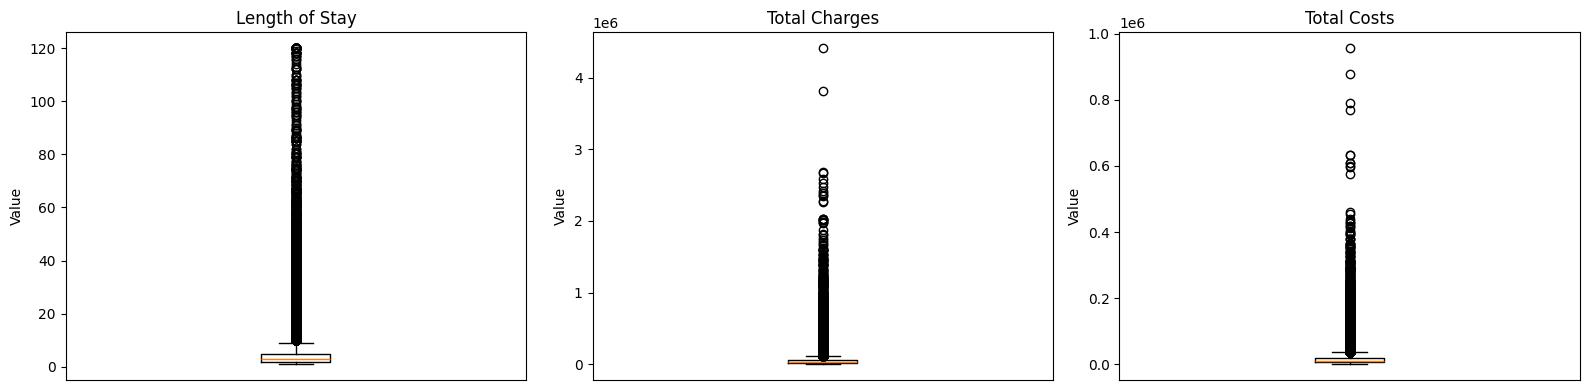

In [ ]:
num_cols = ["Length of Stay", "Total Charges", "Total Costs"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

- The dataset is lognormal - not normal in total charges and total costs
- LOS very skewed even after log transformation. Huge number of small stays. Small number of very long stays
- OUTLIERS ARE NOT ERROS. WE SHOULD NOT REMOVE THEM
- Mean does not show much. MEDIAN is more important


Right-skewness in all numerical variables, particularly in Total Charges and Total Costs, where extreme outliers are observed. These outliers represent high-cost cases and are normal to healthcare data  
Log transformation provides a clearer view of the underlying distributions, revealing that both cost-related variables follow an approximately log-normal distribution.  
Length of Stay remains skewed even after transformation, reflecting the clinical nature of hospital stays.

## Log Normal Outlier Identification


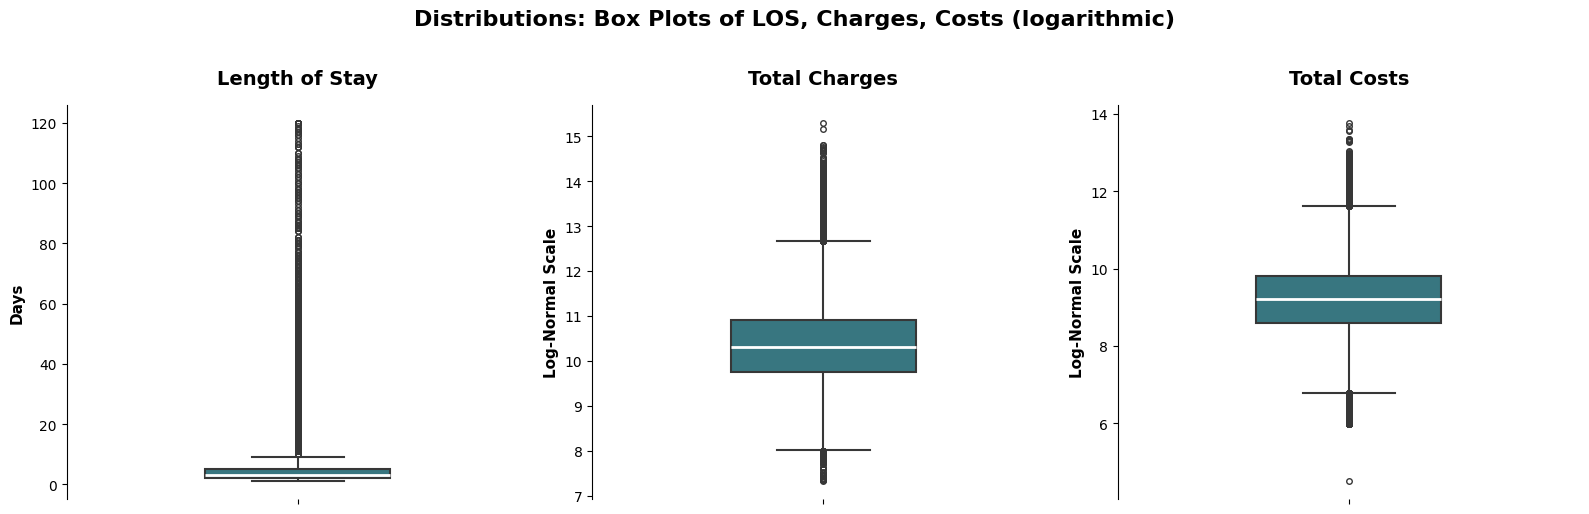

In [ ]:
# Select the "Middle" color from the Crest palette
crest_teal = sns.color_palette("crest", n_colors=10)[5]

# Set up the figure with a transparent background
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='none')

cols = ["Length of Stay", "Total Charges", "Total Costs"]

for i, col in enumerate(cols):
    # Handle the data: use log transformation for financial columns
    x = df[col].dropna()

    if col != "Length of Stay":
        # log1p is better as it handles zero values safely
        plot_data = np.log1p(x)
        label = "Log-Normal Scale"
    else:
        plot_data = x
        label = "Days"

    # Create the boxplot using Seaborn for better styling control
    sns.boxplot(y=plot_data, ax=axes[i], color=crest_teal,
                width=0.4, fliersize=4,
                linewidth=1.5, medianprops={"color": "white", "linewidth": 2})

    # Remove background of individual plots
    axes[i].set_facecolor('none')

    # Professional labeling
    axes[i].set_title(f"{col}", fontsize=14, fontweight='bold', color='black', pad=15)
    axes[i].set_ylabel(label, fontsize=11, fontweight='bold', color='black')
    axes[i].set_xlabel("")

    # Despine: remove the box borders for a modern look
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('black')
    axes[i].spines['bottom'].set_visible(False) # Bottom spine not needed for 1-column boxplot

    # Ensure grid lines are off for a minimalist look
    axes[i].grid(False)
    plt.suptitle("Distributions: Box Plots of LOS, Charges, Costs (logarithmic)",

             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

plt.show()

## Outlier Conclusion
While outliers in 'Minor' cases were investigated as potential noise, we retained outliers in 'Extreme' severity cases as they represent the high-cost reality of complex clinical care

# Understanding Variables - Univariate Analysis

## Numeric

In [ ]:
# After conversion
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

In [ ]:
print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: Index(['Length of Stay', 'Year', 'Total Charges', 'Total Costs'], dtype='object')
Categorical Columns: Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Admission Type', 'Patient Disposition', 'Diagnosis',
       'Severity of Illness', 'Risk of Mortality', 'Payment Type',
       'ED Indicator'],
      dtype='object')


In [ ]:
df[numeric_cols].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Length of Stay,107682.0,5.055980,7.440349,1.00,2.00,3.000,5.0000,120.00
Year,107682.0,2018.495682,0.499984,2018.00,2018.00,2018.000,2019.0000,2019.00
Total Charges,107682.0,52578.678601,88236.674008,1500.00,17181.89,29873.045,55216.6475,4409949.53
Total Costs,107682.0,15946.164155,22726.076002,88.27,5410.03,9974.455,18189.6025,956351.23


In [ ]:
# Summary statistics
summary = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary["skew"] = df[numeric_cols].skew(numeric_only=True)
summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
Length of Stay,107682.0,5.055980,7.440349,1.00,1.0000,1.0000,2.00,3.000,5.0000,15.000,35.0000,120.00,7.435743
Year,107682.0,2018.495682,0.499984,2018.00,2018.0000,2018.0000,2018.00,2018.000,2019.0000,2019.000,2019.0000,2019.00,0.017274
Total Charges,107682.0,52578.678601,88236.674008,1500.00,4455.2673,6052.0000,17181.89,29873.045,55216.6475,168937.794,381260.6335,4409949.53,10.163514
Total Costs,107682.0,15946.164155,22726.076002,88.27,791.1400,947.5245,5410.03,9974.455,18189.6025,49996.698,103110.3964,956351.23,8.046440


**LOS**  
LOS is highly right-skewed, with a median of 3 days and a mean of 5 days. While most discharges occur within 5 days, a small number of cases extend to significantly longer durations, reflecting complex or severe conditions. Only 4% remain more than 15 days

**Total Charges**  
 exhibit a highly right-skewed distribution, with a median of approximately USD 30K, and a mean of  USD 54K. A small proportion of cases accounts for extremely high charges, as indicated by the 99th percentile exceeding $379,000 and a maximum above  USD 4.4 million.

 **Total Costs**  
 also demonstrate significant right-skewness, with a median of approximately  USD 10K and a mean of UD 16K. Similar to total charges, a small number of cases incur substantially higher costs.”

**Numeric Columns Distributions**

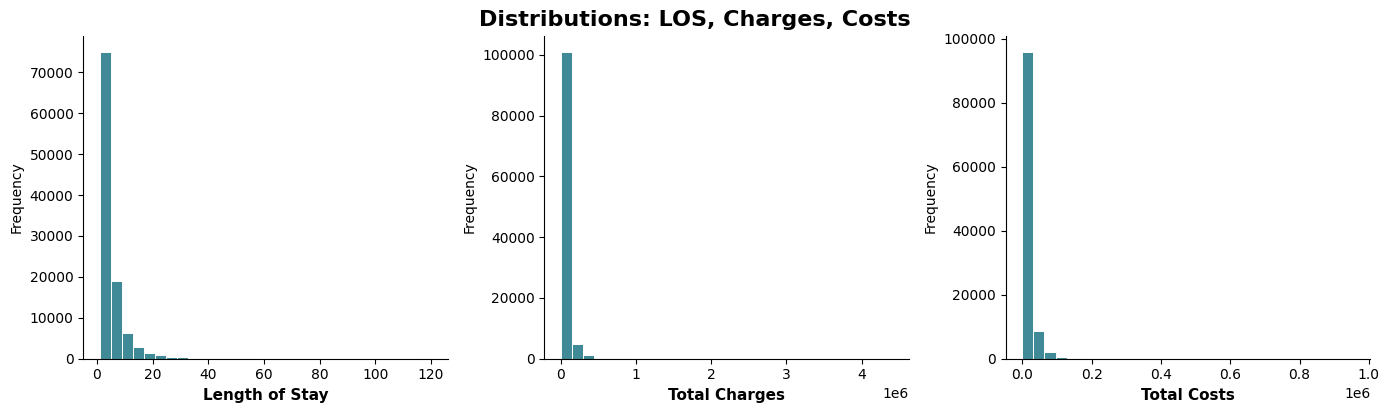

In [ ]:
# Select the "Middle" color from the Crest palette
crest_teal = sns.color_palette("crest", n_colors=10)[5]
selected_cols = ['Length of Stay','Total Charges','Total Costs']
n = len(selected_cols)
cols = 3
rows = math.ceil(n / cols)

# Initialize the figure with a transparent background
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), facecolor='none')
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    # Plotting with the specific middle-crest teal
    sns.histplot(df[col].dropna(), bins=30, kde=False, ax=axes[i],
                 color=crest_teal, edgecolor='white', alpha=0.9)

    # Remove background of the individual plot area
    axes[i].set_facecolor('none')

    # Minimalist, bold labels for high-contrast slides
    axes[i].set_xlabel(col, fontsize=11, fontweight='bold', color='black')
    axes[i].set_ylabel("Frequency", fontsize=10, color='black')

    # Despine: remove borders
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('black')
    axes[i].spines['bottom'].set_color('black')

    # Ensure grid lines are off
    axes[i].grid(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.suptitle("Distributions: LOS, Charges, Costs",

             fontsize=16, fontweight='bold', y=1.02)


plt.show()

Due to very large values coexisting with very small, we also check how the logarithm of the variables behaves with regard to distributions

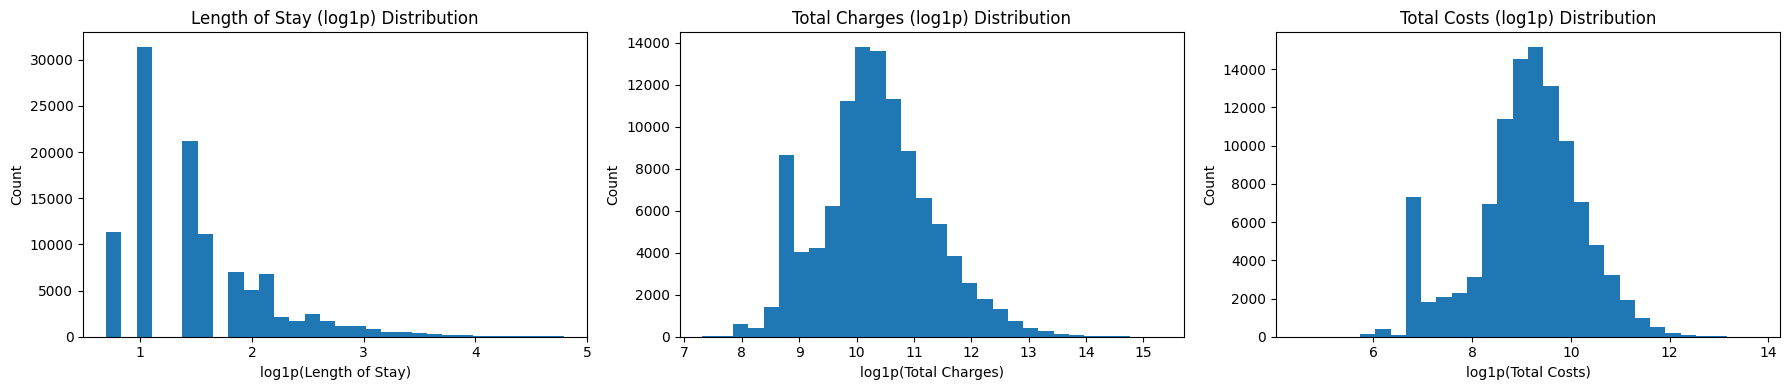

In [ ]:
num_cols = ["Length of Stay", "Total Charges", "Total Costs"]
num_cols = [c for c in num_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

# If only one numeric column, make axes iterable
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    x = df[col].dropna()
    axes[i].hist(np.log1p(x), bins=30)
    axes[i].set_title(f"{col} (log1p) Distribution")
    axes[i].set_xlabel(f"log1p({col})")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

“Log-transformed distributions of Total Charges, and Total Costs show an almost normal shape.  **log-normal distributions**
**This suggests that extreme values observed in the raw data are not anomalies but characteristics of healthcare utilization, where a only a very small number of cases incur disproportionately high costs.”

Total Charges and Total costs seem to follow the same shape. **STRONG RELATIONSHIP**

In [ ]:
df.columns

Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs'],
      dtype='object')

## Categorical

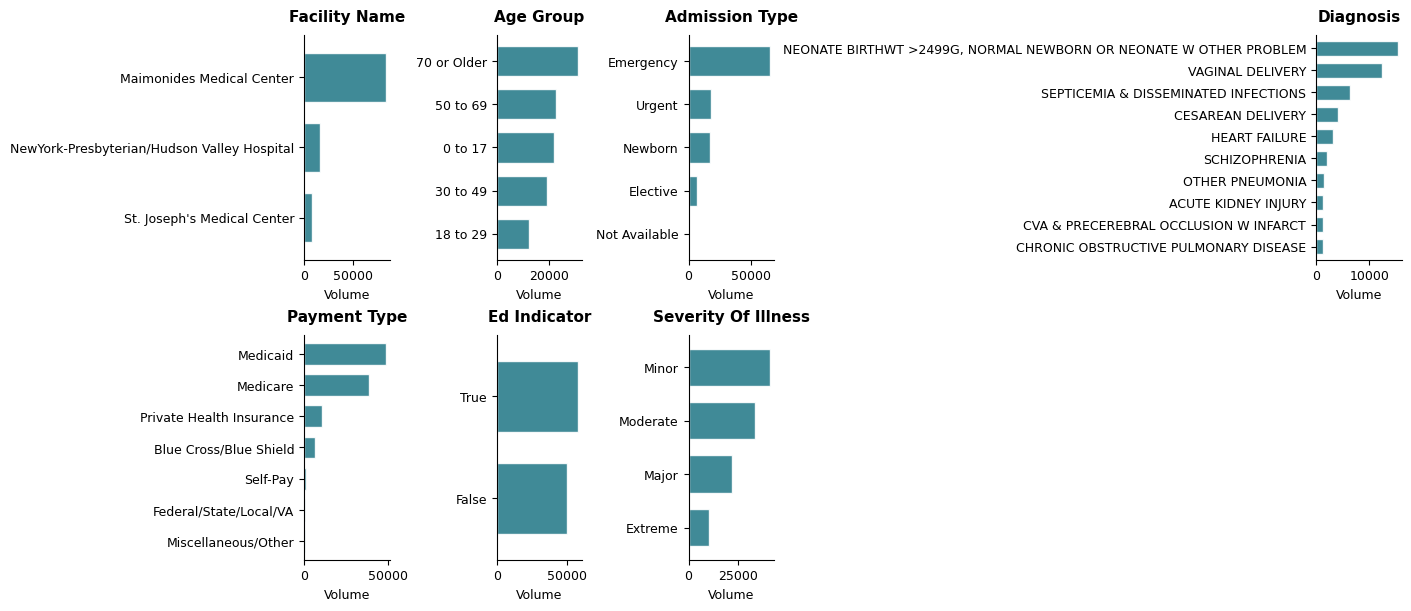

In [ ]:
# Define specific categories for the report
target_cols = [
    'Facility Name', 'Age Group', 'Admission Type',
    'Diagnosis', 'Severity of Illenss', 'Payment Type', 'ED Indicator','Severity of Illness'
]

# Filter for existing columns and setup styling
cat_cols = [c for c in target_cols if c in df.columns]
crest_teal = sns.color_palette("crest", n_colors=10)[5]
n = len(cat_cols)
cols = 4
rows = math.ceil(n / cols)

# Initialize figure with constrained layout for better report spacing
fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows), facecolor='none', constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Process top 10 categories
    vc = df[col].value_counts().head(10).sort_values()

    # Create horizontal bars
    vc.plot(kind='barh', ax=axes[i], color=crest_teal, edgecolor='white', alpha=0.9, width=0.7)

    # Clean aesthetic for professional output
    axes[i].set_facecolor('none')
    axes[i].set_title(f"{col.title()}", fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel("Volume", fontsize=9)
    axes[i].set_ylabel("")

    # Remove axis borders and gridlines
    sns.despine(ax=axes[i])
    axes[i].grid(False)
    axes[i].tick_params(axis='both', labelsize=9)

# Clean up empty subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

**Insights**  
- Mamonidis dominates (Larger hospital results)
- Most people are of >70 years of age (skewed to older population)
- Women are more than men
- Emergency Admission dominates massively (hospitals operate reactively)
- 80% of emergency admissions end up in the Emergency Department
- Most payments are by Medicaid and Medicare  (public Insurance Programs)
- Most admissions are for minor severity cases
- Not so big danger for mortality
- Most patients are discharged to go to Home or Selfcare (recovery with no long term needs)
- Emergency Department
- Most cases are fpr early birth. vaginal delivery and septicemia (accute infections), Cesarean Delivery



# Looking at Admissions and Emergency Deparment correlation

In [ ]:
ct = pd.crosstab(df['Admission Type'], df['ED Indicator'], normalize='index') * 100
print("Percentage of Admissions using the Emergency Dept:")
print(ct)

Percentage of Admissions using the Emergency Dept:
ED Indicator        False      True 
Admission Type                      
Elective        99.368814   0.631186
Emergency       20.768727  79.231273
Newborn         99.946834   0.053166
Not Available   88.000000  12.000000
Urgent          68.512667  31.487333


# Feature Engineering

In [ ]:
#Create 2 KPIs
df["Charge per Day"] = df["Total Charges"] / df["Length of Stay"]
df["Cost per Day"] = df["Total Costs"] / df["Length of Stay"]
# Charge to Cost Ratio. This can be the slope of the line.
df['CCR'] = df['Total Charges'] / df['Total Costs']

In [ ]:
#Markup
df['Markup Amount'] = df['Total Charges'] - df['Total Costs']

#Markup %
df['Markup %'] = (df['Markup Amount'] / df['Total Costs']) * 100

## Change some data names so as to deliver results easier ##

In [ ]:
# Selected 1, because there are no NANs
# Unify : Federal/State/Local + Medicaid
# Unify : Private Health  + BlueCross/Blue
#'Self-Pay': 'Self-Pay/Other',
# 'Miscellaneous/Other': 'Self-Pay/Other',

Group the Isurance types, so as to have mainly Federa, Federal + State, Private, Self-Pay/Others

In [ ]:
df['Payment Type'].value_counts()

,count
Payment Type,
Medicaid,48870
Medicare,39108
Private Health Insurance,10589
Blue Cross/Blue Shield,6807
Self-Pay,1153
Federal/State/Local/VA,605
Miscellaneous/Other,550


## Payment Type Data and Hospital Data ##

In [ ]:
# Define the Mapping Dictionary with the  exact naming conventions
# Based on the requirement: Medicaid, Medicare, Private, and Self-Pay/Other
payer_mapping = {
    # Group: Medicaid
    'Medicaid': 'Medicaid',
    'Federal/State/Local/VA': 'Medicaid',

    # Group: Medicare
    'Medicare': 'Medicare',
    # Group: Private
    'Blue Cross/Blue Shield': 'Private',
    'Private Health Insurance': 'Private',


    # Group: Self-Pay/Other
    'Self-Pay': 'Self-Pay/Other',
    'Miscellaneous/Other': 'Self-Pay/Other',

}
facility_mapping = {
    'Maimonides Medical Center': 'Maimonides',
    'NewYork-Presbyterian/Hudson Valley Hospital': 'Hudson Valley',
    'St. Joseph\'s Medical Center': 'St. Josephs'
}

df['Payment Type'] = df['Payment Type'].replace(payer_mapping)
df['Facility Name'] = df['Facility Name'].replace(facility_mapping)


# Clean data Sanity Check
print("Unique Payer Groups:", df['Payment Type'].unique())
print("Unique Facilities:", df['Facility Name'].unique())

Unique Payer Groups: ['Medicaid' 'Medicare' 'Private' 'Self-Pay/Other']
Unique Facilities: ['Maimonides' 'Hudson Valley' 'St. Josephs']


## Understanding Variables - Bivariate Analysis

Before Building Correlation Matrices, we are going to associate numbers to "Severity of Ilness" and "Risk of Mortality". Both get teh same values from 1-4. And correlation maps could be created. Also do the same for the case of Age groups.  
For all these features it makes sense to categorize them from 1-5, since they have a weight of severity anyway.

In [ ]:
#Mappins of severity
risk_severity_map = {"Minor": 1, "Moderate": 2, "Major": 3, "Extreme": 4}
#Mappings of Age bins
age_map = {
    "0 to 17": 1,
    "18 to 29": 2,
    "30 to 49": 3,
    "50 to 69": 4,
    "70 or Older": 5
}

# Create Rank Columns
# We keep the original text columns for hte Dashboard labels
df['Severity_Rank'] = df['Severity of Illness'].map(risk_severity_map)
df['Mortality_Rank'] = df['Risk of Mortality'].map(risk_severity_map)
df['Age_Rank'] = df['Age Group'].map(age_map)

## **Correlation Matrix**

In [ ]:
#Columns to Correlate
#Taken out the Total Charges as it behaves teh same way as Total Costs
corr_cols = [
    'Total Costs',
 #   'Total Charges',
    'Length of Stay',
    'Severity_Rank',
    'Mortality_Rank',
    'Age_Rank',
    'Cost per Day',
    'Charge per Day',
    'Markup Amount',
    'Markup %'
]

In [ ]:
df[corr_cols].head()

,Total Costs,Length of Stay,Severity_Rank,Mortality_Rank,Age_Rank,Cost per Day,Charge per Day,Markup Amount,Markup %
0,3447.96,1,2,1,1,3447.9600,7983.000000,4535.04,131.528208
1,6475.87,4,3,3,5,1618.9675,5938.005000,17276.15,266.777282
2,24953.85,15,2,1,1,1663.5900,11701.800667,150573.16,603.406528
3,957.17,2,1,1,1,478.5850,3001.000000,5044.83,527.056845
4,26080.60,7,3,2,2,3725.8000,13295.161429,66985.53,256.840448


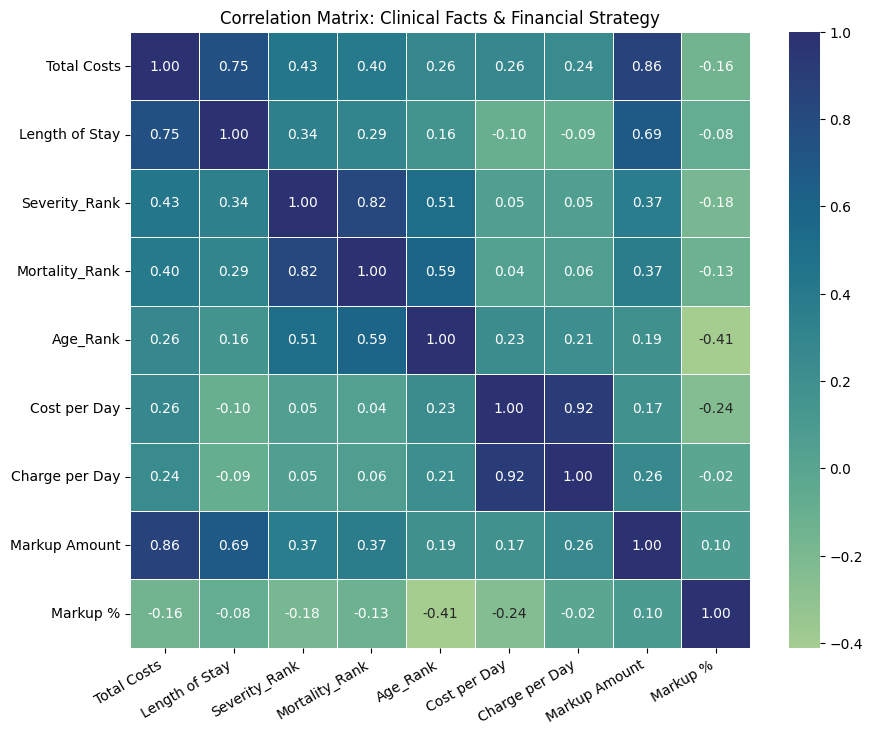

In [ ]:
#Correlation Matrix
corr_matrix = df[corr_cols].corr()

# Plot using Seaborn
plt.figure(figsize=(10, 8))
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            #mask = mask,
            annot=True,      # This depicts the numbersc
            fmt=".2f",       # Rounds to 2 decimal places
            cmap='crest',  #  chosen color scale
            linewidths=0.5)  # Adds lines between cells for clarity
plt.xticks(rotation=30, ha='right')
plt.title("Correlation Matrix: Clinical Facts & Financial Strategy")
plt.show()

**Insight**



1.   correlation ($0.75$) between Length of Stay (LOS) and Total Costs.The Insight: This proves that the hospital's primary cost driver is "time in bed." (Director --> Any policy including LOS will have a big impact in the bottomline
2.   Length of Stay and Cost per Day ($-0.10$) The expensive stuff (surgery, scans, ER intake) happens in the first 1-2 days. After that a patient is mostly just incurring "room and board" costs. (C-Level)


3.   ($0.82$) between Severity_Rank and Mortality_Rank. - Validation of Data Cleaning is correct. High severity  and high mortality go together
4.   Age_Rank has a positive correlation (0.19) with Markup amount, as age increases in brings slightly more mone, and small negative correlation ($-0.41$) with Markup_perc. As patients get older, the hospital's markup (profit buffer) becomes smaller.

5.   total Cost and Markup amount (86%) - Mardup % (-0=16%) with Total Cost.: Volume is high but efficiency is small . For expensive Cased the hospital is billing more but their profit efficiency actually drops slightly ($-0.16$)
6.   Markup Amount vs LOS : 69% byt Markup % again the same. The longer the LOS the less the efficiency of cost - cost almost equal to charges-- but more dollars


7.   Rank of severity and Mortality with Markup Amount : 37%."Extreme" cases are not charged too higher than "Minor" ones. They are following a more linear billing path, which might be a risk if the costs for "Extreme" cases spike unexpectedly.





5




## CrossTab : Operational Insight - Admissions and Emergency Department Association

In [ ]:
ct = pd.crosstab(df['Admission Type'], df['ED Indicator'], normalize='index') * 100
print("Percentage of Admissions using the Emergency Dept:")
print(ct)

Percentage of Admissions using the Emergency Dept:
ED Indicator        False      True 
Admission Type                      
Elective        99.368814   0.631186
Emergency       20.768727  79.231273
Newborn         99.946834   0.053166
Not Available   88.000000  12.000000
Urgent          68.512667  31.487333


Insight: 80% of Admission type Emergency have an invoice with ED Indicator

# Scatter plots

Where is the pricing power of hospitals? Which payment method?

## Finding how each hospital uses each Payment type

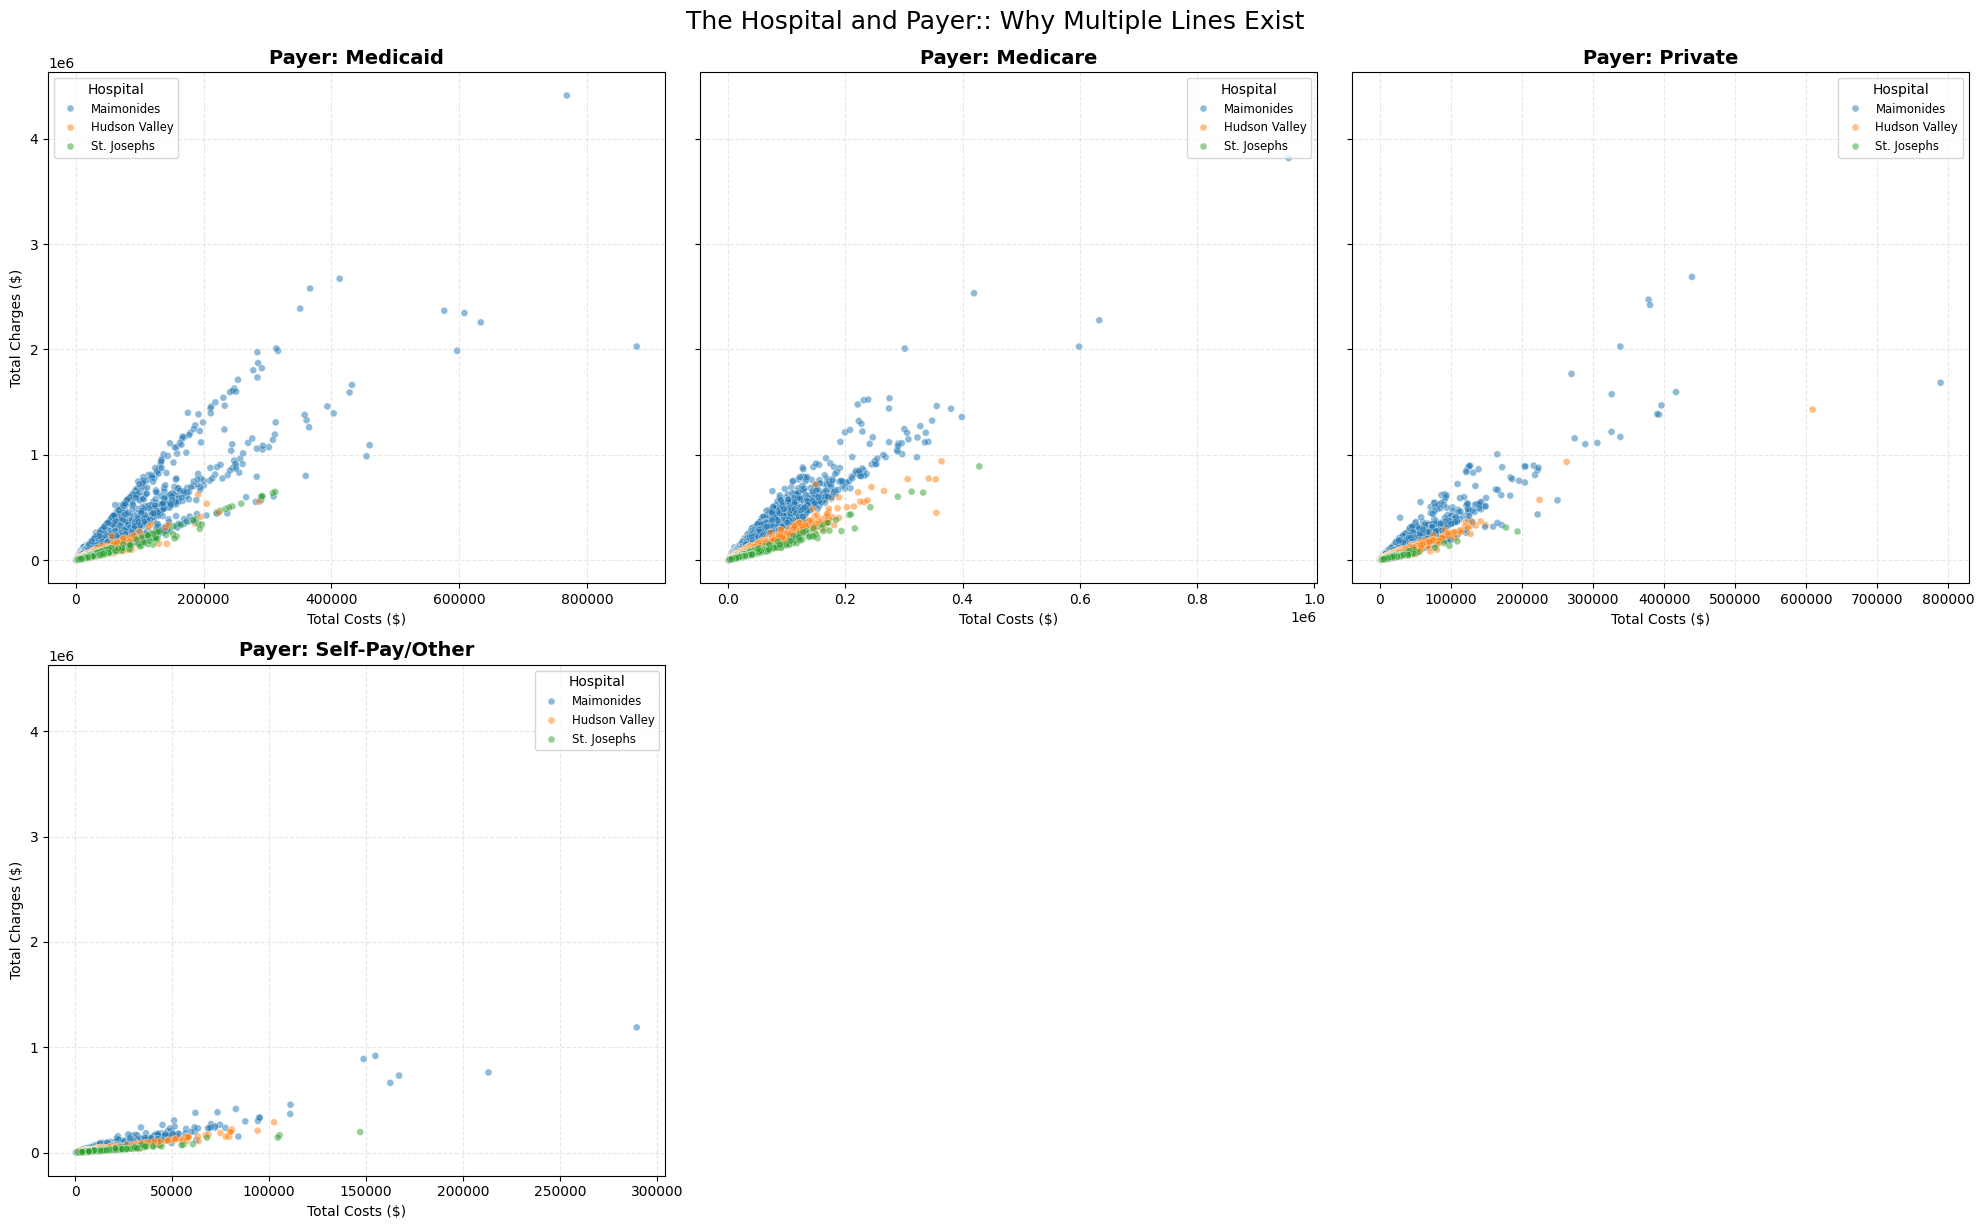

In [ ]:
#  Get the list of payers
target_payers = df['Payment Type'].unique().tolist()
num_payers = len(target_payers)

# Dynamically calculate the grid size (e.g., 3 columns wide)
cols = 3
rows = math.ceil(num_payers / cols)

# Create the figure with the correct number of rows/cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows), sharey=True)

# Flatten axes array so we can iterate easily even if it's 2D
axes_flat = axes.flatten()

for i, payer in enumerate(target_payers):
    subset = df[df['Payment Type'] == payer]

    # Plot on the current flattened index
    sns.scatterplot(
        data=subset,
        x='Total Costs',
        y='Total Charges',
        hue='Facility Name',
        alpha=0.5,
        s=25,
        ax=axes_flat[i]
    )

    axes_flat[i].set_title(f"Payer: {payer}", fontsize=14, fontweight='bold')
    axes_flat[i].set_xlabel("Total Costs ($)")
    axes_flat[i].set_ylabel("Total Charges ($)")
    axes_flat[i].grid(True, linestyle='--', alpha=0.3)
    axes_flat[i].legend(title="Hospital", loc='best', fontsize='small')

# Clean up: Hide any empty subplots (if num_payers is 4, but grid is 2x3, hide the last 2)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.suptitle("The Hospital and Payer:: Why Multiple Lines Exist", fontsize=18, y=1.02)
plt.show()

Insights  
- Maimonidis is always higher in Charges per cost. For all payment types.

##**See the Total Costs vs Total Charges per 3 hospitals**

### Regression to find the slopes for each hospital

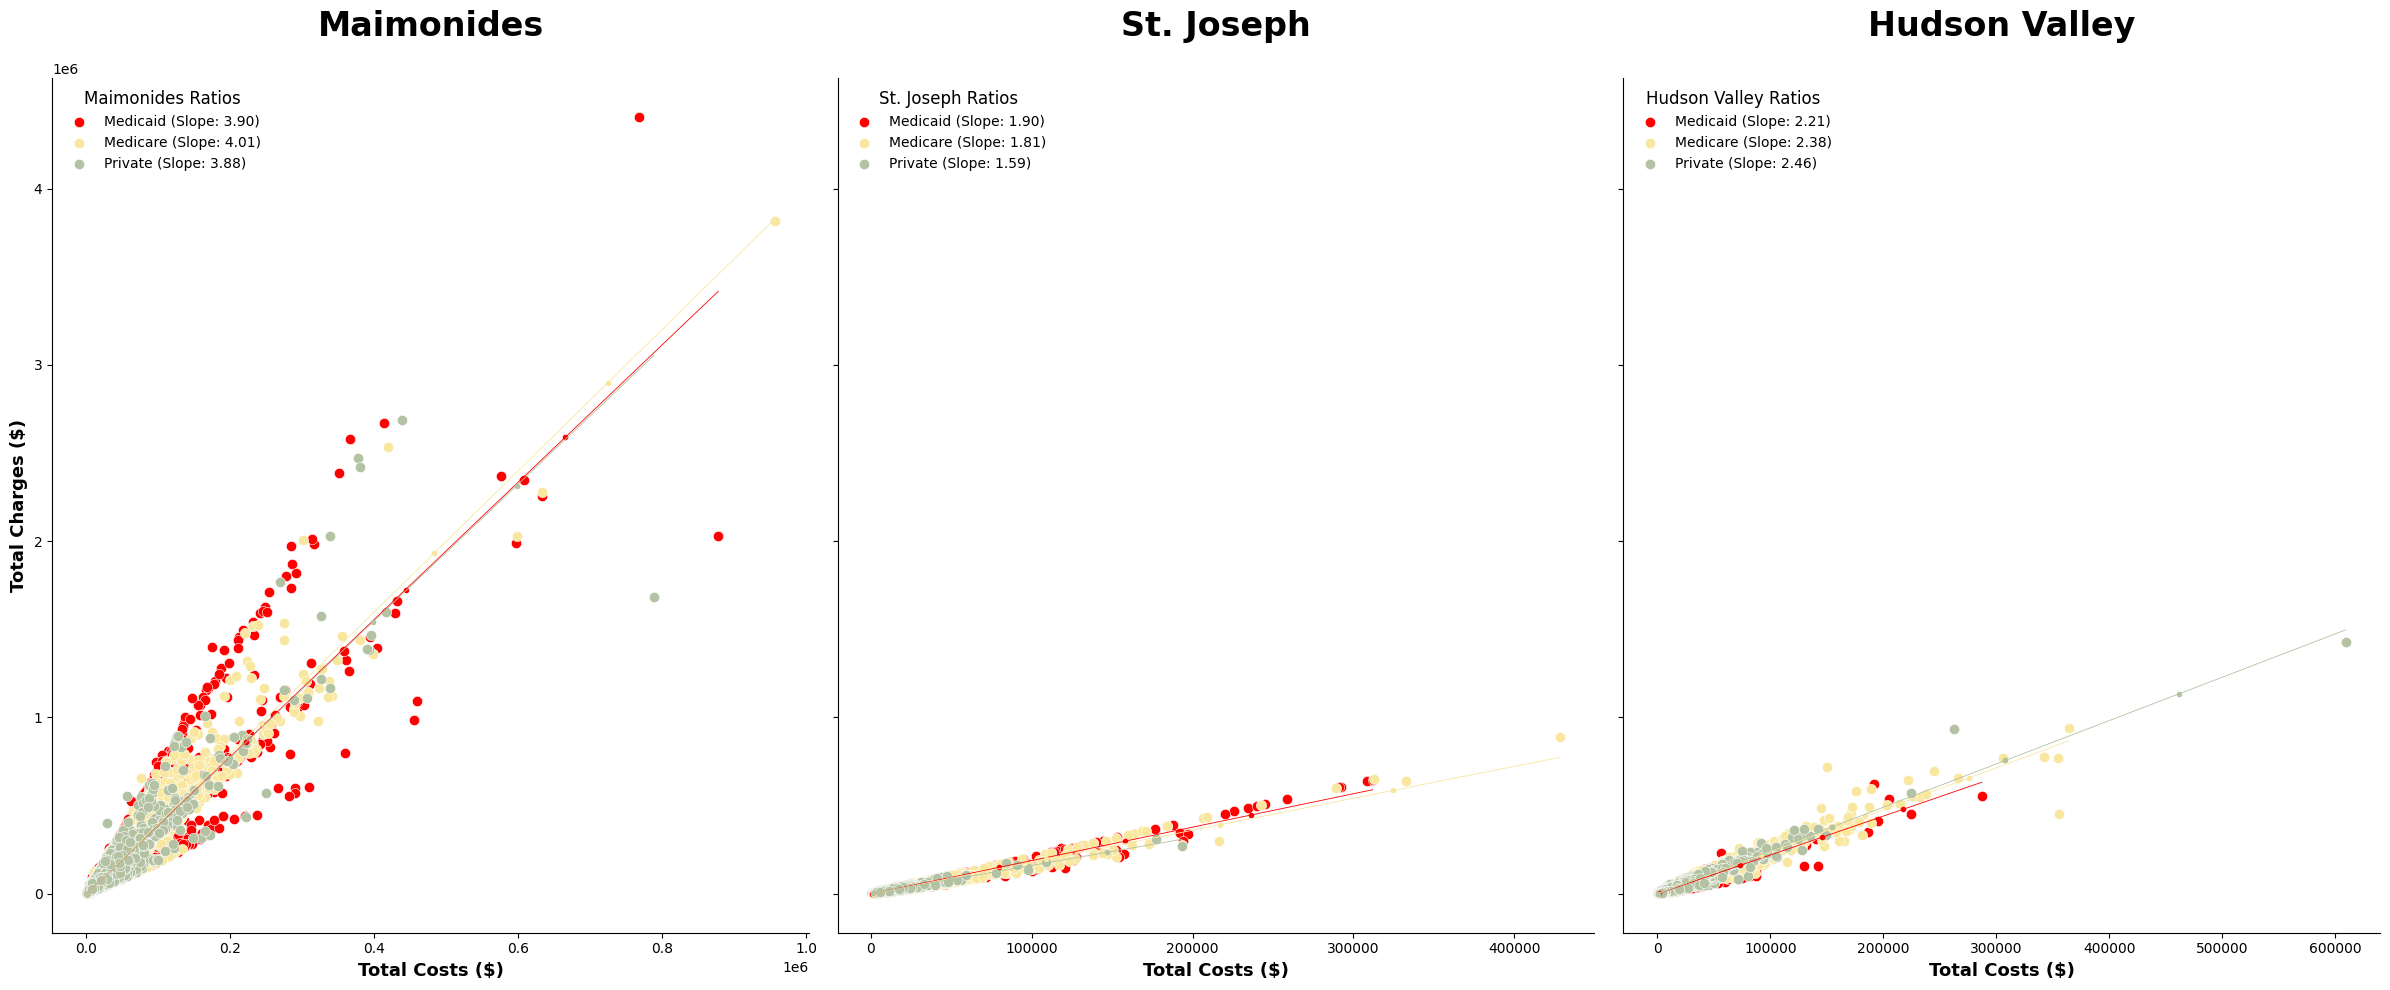

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Strategic Color Palette (Visual Hierarchy)
custom_colors = {
    'Medicaid': '#FF0000',
    'Medicare': '#F9E79F',
    'Private': '#B2C2A2'
}

# Filter for core comparison
facilities = ['Maimonides', 'St. Joseph', 'Hudson Valley']
payers = ['Medicaid', 'Medicare', 'Private']
filtered_df = df[df['Payment Type'].isin(payers)].copy()

# Setup the 1x3 transparent grid
fig, axes = plt.subplots(1, 3, figsize=(24, 10), facecolor='none', sharey=True)

for i, hospital_name in enumerate(facilities):
    h_subset = filtered_df[filtered_df['Facility Name'].str.contains(hospital_name, case=False, na=False)].copy()
    ax = axes[i]
    ax.set_facecolor('none')

    legend_handles = []

    for payer in payers:
        p_subset = h_subset[h_subset['Payment Type'] == payer].dropna(subset=['Total Costs', 'Total Charges'])

        if not p_subset.empty:
            scatter = ax.scatter(p_subset['Total Costs'], p_subset['Total Charges'],
                                 color=custom_colors[payer], s=55, alpha=1.0,
                                 edgecolor='white', linewidth=0.4)

            # Calculation happens for EVERY hospital here
            if len(p_subset) > 15:
                X = p_subset[['Total Costs']].values
                y = p_subset['Total Charges'].values
                model = LinearRegression().fit(X, y)
                slope = model.coef_[0]

                x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
                y_pred = model.predict(x_range)
                ax.plot(x_range, y_pred, color=custom_colors[payer],
                        lw=0.6, linestyle='-', marker='o', markersize=3, markevery=25)

                # This label is specific to the current hospital in the loop
                scatter.set_label(f"{payer} (Slope: {slope:.2f})")
            else:
                scatter.set_label(payer)

            legend_handles.append(scatter)

    # REFINED LOGIC: Put a legend on EVERY graph so we see the individual slopes
    ax.legend(handles=legend_handles, title=f"{hospital_name} Ratios",
              title_fontsize='12', fontsize='10', loc='upper left',
              frameon=True, facecolor='white', framealpha=0.6, edgecolor='none')

    # Formatting
    ax.set_title(hospital_name, fontsize=24, fontweight='bold', pad=30, color='black')
    ax.set_xlabel("Total Costs ($)", fontsize=13, fontweight='bold')

    if i == 0:
        ax.set_ylabel("Total Charges ($)", fontsize=13, fontweight='bold')
    else:
        ax.set_ylabel("")

    sns.despine(ax=ax)
    ax.grid(False)

plt.tight_layout()
#plt.savefig('all_hospital_slopes.png', transparent=True, dpi=300)
plt.show()

This is interesting as for Maimonides, Medicaid has 3 separate trajectories for a given cost.

The analysis of the scatterplots in the figure above,  indicates that Maimonides has a different billing pattern compared to St. Joseph’s and Hudson Valley. At Maimonides, pricing lines are separated for the Payment Types. Particularly for Medicaid, this appears along three distinct trajectories. This suggests the presence of payer‑specific pricing structures, likely reflecting different contractual or disease specific detailed pricing requirements.
Maimonides serves a very large Medicaid population and rely on differentiated markups for insured patients, which can create visible separation in prices for identical services. The steep slopes observed in Maimonides’ pricing relationships indicate that increases in listed charges translate into substantially higher collected amounts for specific payer types.
In contrast, St. Joseph’s and Hudson Valley display much narrower and closely clustered pricing lines across payer categories. This suggests the presence of a more standardized charges, where prices vary less by payer type. Their lower slopes imply that hospital costs result in comparatively smaller increases in actual payments.
Overall, the findings point to two distinct billing approaches.
St. Joseph’s and Hudson Valley follow a relatively standardized pricing model, with uniform markups across payers.
Maimonides follows a more differentiated strategy, consistent with broader cross‑subsidization behavior and the financial pressures associated with serving a high‑Medicaid population.
This tells us that hospital billing is not merely a product of insurance type, but a specific 'Institutional’ issue. This proves that while the 'PayerType' determines the general revenue tier, the 'Facility' determines the absolute markup buffer, indicating a standardized but facility-specific pricing strategy.


We decided to isolate Maimonides and specifically for Medicaid Costs and Charges and run KMeans clustering for 3 distinct clusters based on pricing. What we found may be seen in the clustermap below.





**The "Standardized" vs "Strategic" Billing**  
***St. Joseph's*** : Notice how all the lines at St. Joseph's are very close together. This suggests they aren't "negotiating" aggressively. They have a low, flat markup for everyone. This is "fair," but financially dangerous in a high-cost environment like NY.

***Maimonides***: Maimonides has a huge gap between the Red (Medicaid) and Green (Private) lines. This shows they are Cross-Subsidizing. They know Medicaid pays poorly, *so they charge Private insurance a massive markup to try and balance the books.*

Hospital billing is not merely a product of insurance type, but a specific 'Institutional Signature.' By isolating each payment type, we observe that each facility (e.g., Maimonides vs. St. Joseph) maintains its own rigid linear markup factor (Charge-to-Cost Ratio).   
This proves that while the 'PayerType' determines the general revenue tier, the 'Facility' determines the absolute markup trajectory, indicating a standardized but facility-specific pricing strategy."

### Analyzing Maimonidis - Check if we can identify the reason for the triplet

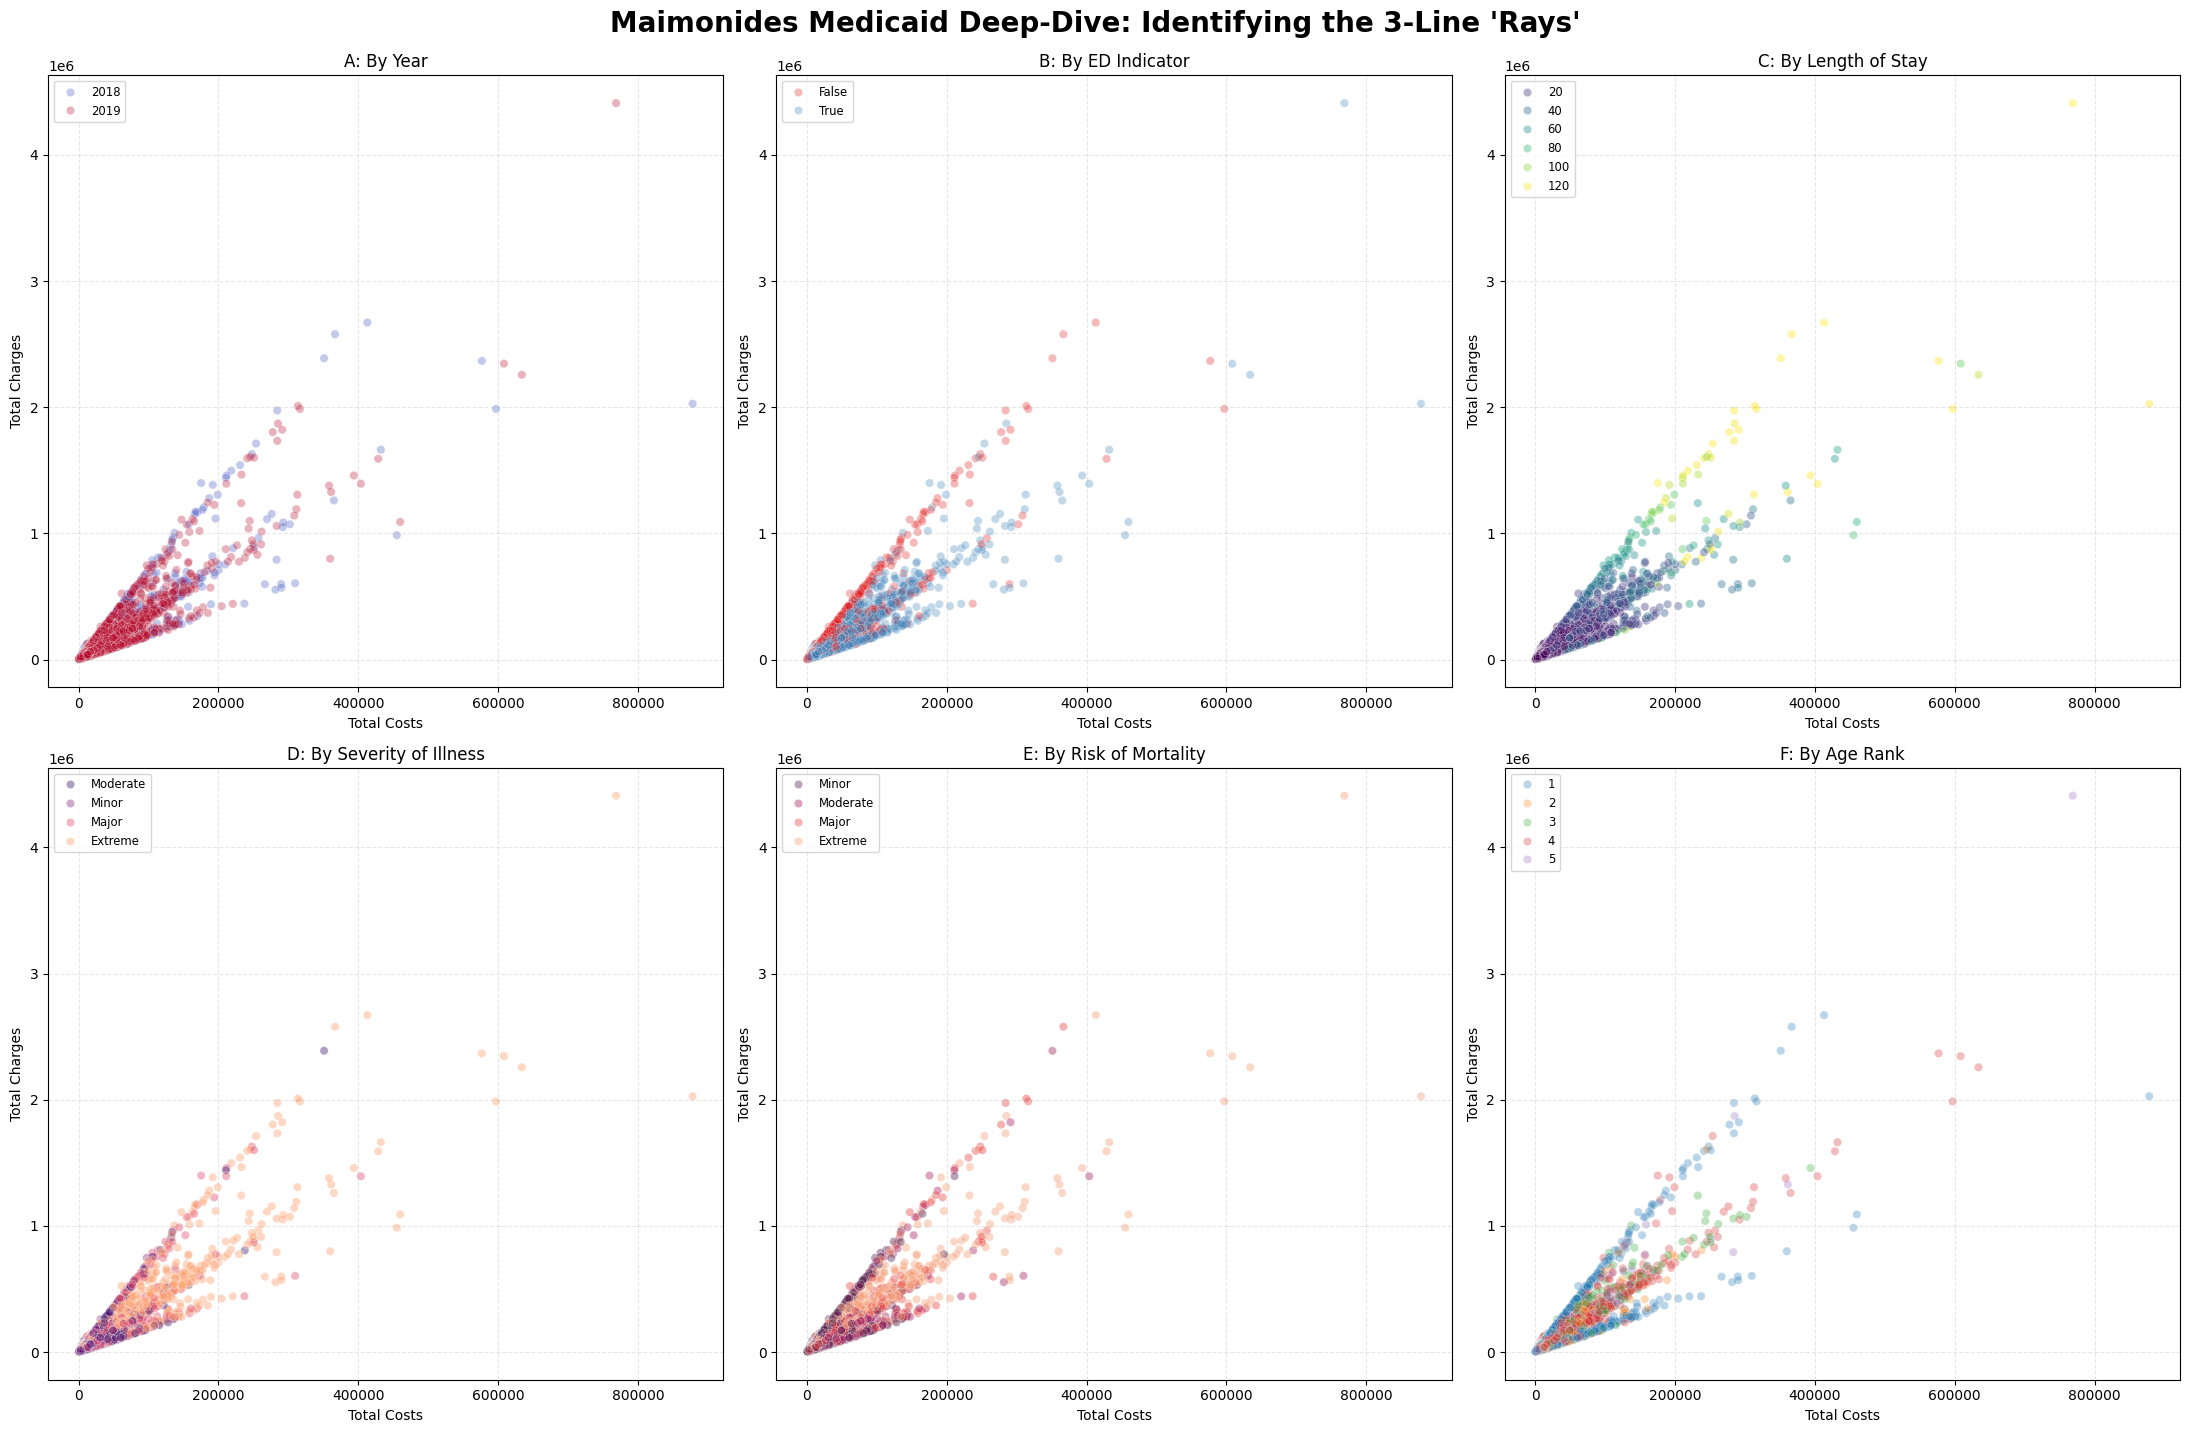

In [ ]:

# Filter Maimonidis and Medicaid
df_maimo_medicaid = df[(df['Facility Name'].str.contains('Maimonides', case=False)) &
                       (df['Payment Type'] == 'Medicaid')].copy()


fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten() # Flatten for easy 0-5 indexing

# The Year (Historical Shift)
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='Year', palette='coolwarm', alpha=0.3, ax=axes[0])
axes[0].set_title("A: By Year")

#  Emergency Dept (Operational Split)
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='ED Indicator', palette='Set1', alpha=0.3, ax=axes[1])
axes[1].set_title("B: By ED Indicator")

# Length of Stay (Efficiency/Duration)
# Using a sequential palette to show stay duration
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='Length of Stay', palette='viridis', alpha=0.4, ax=axes[2])
axes[2].set_title("C: By Length of Stay")

#Severity of Illness (Clinical Intensity)
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='Severity of Illness', palette='magma', alpha=0.4, ax=axes[3])
axes[3].set_title("D: By Severity of Illness")

# : Risk of Mortality (Clinical Risk)
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='Risk of Mortality', palette='rocket', alpha=0.4, ax=axes[4])
axes[4].set_title("E: By Risk of Mortality")

# Age Group or Age_Rank (Demographic)
sns.scatterplot(data=df_maimo_medicaid, x='Total Costs', y='Total Charges',
                hue='Age_Rank', palette='tab10', alpha=0.3, ax=axes[5])
axes[5].set_title("F: By Age Rank")

# Formatting
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize='small', loc='upper left', bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.suptitle("Maimonides Medicaid Deep-Dive: Identifying the 3-Line 'Rays'", fontsize=20, y=1.02, fontweight='bold')
plt.show()

No definite conclusion as to what causes the triplet in Total Charges


### KMeans Identify the clusters in Medicaid for Maimonidis


In [ ]:

# Isolate Medicaid data for a Maimonides, triplets of charges vs Cost --> 3 Clusters
medicaid_df = df[(df['Payment Type'] == 'Medicaid') & (df['Facility Name'].str.contains("Maimonides"))].copy()

In [ ]:
medicaid_df

,Hospital County,Facility Name,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,Patient Disposition,Year,Diagnosis,Severity of Illness,Risk of Mortality,Payment Type,ED Indicator,Total Charges,Total Costs,Charge per Day,Cost per Day,CCR,Markup Amount,Markup %,Severity_Rank,Mortality_Rank,Age_Rank
0,Kings,Maimonides,0 to 17,F,Other Race,Not Span/Hispanic,1,Emergency,Home or Self Care,2018,OTHER PNEUMONIA,Moderate,Minor,Medicaid,False,7983.00,3447.96,7983.000000,3447.960000,2.315282,4535.04,131.528208,2,1,1
3,Kings,Maimonides,0 to 17,M,White,Not Span/Hispanic,2,Newborn,Home or Self Care,2018,"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...",Minor,Minor,Medicaid,False,6002.00,957.17,3001.000000,478.585000,6.270568,5044.83,527.056845,1,1,1
4,Kings,Maimonides,18 to 29,F,Black/African American,Not Span/Hispanic,7,Urgent,Home or Self Care,2018,CESAREAN DELIVERY,Major,Moderate,Medicaid,True,93066.13,26080.60,13295.161429,3725.800000,3.568404,66985.53,256.840448,3,2,2
5,Kings,Maimonides,0 to 17,F,Black/African American,Not Span/Hispanic,3,Newborn,Home or Self Care,2018,"NEONATE BWT 2000-2499G, NORMAL NEWBORN OR NEON...",Major,Minor,Medicaid,False,10897.00,2077.80,3632.333333,692.600000,5.244489,8819.20,424.448936,3,1,1
6,Kings,Maimonides,0 to 17,F,White,Not Span/Hispanic,3,Newborn,Home or Self Care,2018,"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...",Minor,Minor,Medicaid,False,8752.00,1340.84,2917.333333,446.946667,6.527252,7411.16,552.725157,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95423,Kings,Maimonides,70 or Older,F,Other Race,Not Span/Hispanic,3,Emergency,Home or Self Care,2019,OTHER DIGESTIVE SYSTEM DIAGNOSES,Major,Major,Medicaid,True,38587.20,12844.16,12862.400000,4281.386667,3.004260,25743.04,200.426030,3,3,5
95429,Kings,Maimonides,50 to 69,F,White,Not Span/Hispanic,4,Emergency,Home w/ Home Health Services,2019,CARDIAC ARRHYTHMIA & CONDUCTION DISORDERS,Moderate,Major,Medicaid,True,63015.25,16536.49,15753.812500,4134.122500,3.810679,46478.76,281.067869,2,3,4
95434,Kings,Maimonides,0 to 17,F,Other Race,Not Span/Hispanic,37,Emergency,Home or Self Care,2019,KIDNEY & URINARY TRACT INFECTIONS,Moderate,Minor,Medicaid,True,115308.03,60334.39,3116.433243,1630.659189,1.911149,54973.64,91.114935,2,1,1
95436,Kings,Maimonides,50 to 69,F,White,Spanish/Hispanic,42,Emergency,Skilled Nursing Home,2019,CVA & PRECEREBRAL OCCLUSION W INFARCT,Moderate,Minor,Medicaid,True,171655.24,49143.53,4087.029524,1170.084048,3.492937,122511.71,249.293671,2,1,4


In [ ]:
# Isolate Medicaid data for a specific hospital (e.g., Maimonides)
#Specify 3 clusters as seen in the
medicaid_df = df[(df['Payment Type'] == 'Medicaid') & (df['Facility Name'].str.contains("Maimonides"))].copy()

# We cluster based on the 'Ratio' (the Slope) of Charges vs. Cost
medicaid_df['Ratio'] = medicaid_df['CCR']

# Apply KMeans to find the 3 distinct "Slopes"
kmeans = KMeans(n_clusters=3, random_state=42)
medicaid_df['Slope_Group'] = kmeans.fit_predict(medicaid_df[['Ratio']])

# Update the aggregation dictionary
analysis = medicaid_df.groupby('Slope_Group').agg({
    'Ratio': 'mean',                        # The Average Slope/Markup
    'Length of Stay': 'mean',               # Average Duration
    'Total Costs': 'mean',                  # Average Resource Intensity
    'Admission Type': 'nunique',             # 'nunique' tells you how diverse the cases are in that slope
    'Diagnosis' : lambda x: x.mode()[0] if not x.mode().empty else "Unknown", #Most common Disease in the group
    'Facility Name': 'count'
}).rename(columns={'Facility Name': 'Patient_Count'}).sort_values(by='Ratio')

print(analysis)

                Ratio  Length of Stay   Total Costs  Admission Type  \
Slope_Group                                                           
1            2.196785        6.091274  17668.084777               4   
0            3.630946        4.036533  13504.658272               4   
2            6.756506        3.625423   4860.822189               4   

                                                     Diagnosis  Patient_Count  
Slope_Group                                                                    
1                                                SCHIZOPHRENIA           7231  
0                                             VAGINAL DELIVERY          22801  
2            NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...          13004  


Just out of curiosity to see the Silhoutte scores. If the clustering went well

In [ ]:
# We calculate the score for the Medicaid groups we found
# Note: We use the same features we used for K-Means (The 'Ratio')
X_scaled = medicaid_df[['Ratio']]
labels = medicaid_df['Slope_Group']

score = silhouette_score(X_scaled, labels)
print(f"Overall Silhouette Score: {score:.3f}")

# 2. To understand it better, let's look at the score PER group
medicaid_df['Silhouette_Value'] = silhouette_samples(X_scaled, labels)
group_audit = medicaid_df.groupby('Slope_Group')['Silhouette_Value'].mean()
print("\nScore per Clinical Group:")
print(group_audit)

Overall Silhouette Score: 0.712

Score per Clinical Group:
Slope_Group
0    0.650779
1    0.687729
2    0.831482
Name: Silhouette_Value, dtype: float64


Create a clustermap to identify groups

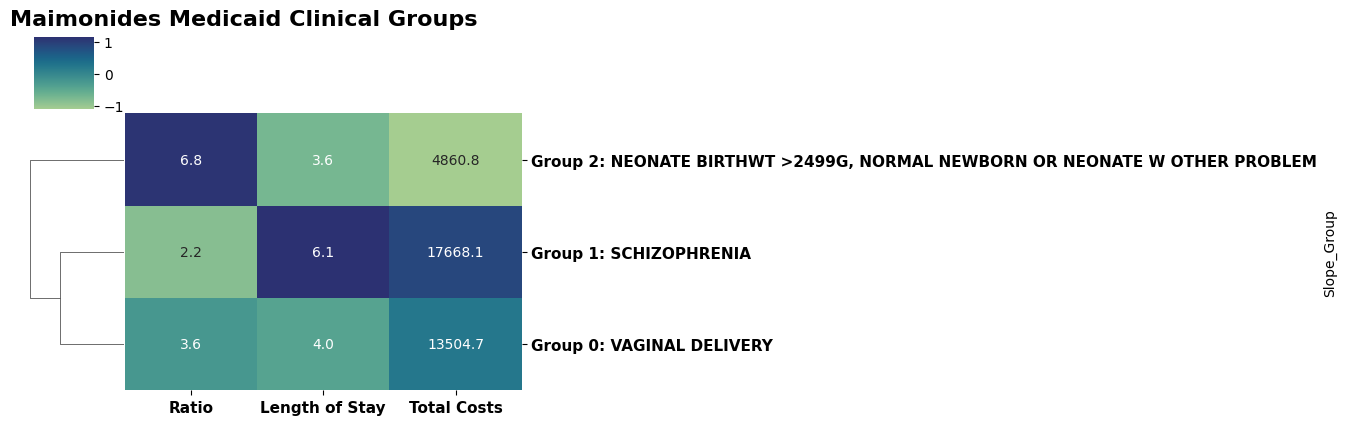

In [ ]:
# Prepare the Data for the Clustermap
# We only use the NUMERIC columns for the actual clustering
cluster_features = ['Ratio', 'Length of Stay', 'Total Costs']
plot_data = analysis[cluster_features]

# Create nice labels that include the Diagnosis Name for the Y-axis
row_labels = [f"Group {i}: {diag}" for i, diag in zip(analysis.index, analysis['Diagnosis'])]

# 3. Generate the Clustermap
# 'z_score=1' normalizes the columns so 'Total Costs' (thousands)
# doesn't drown out 'Length of Stay' (single digits)


g = sns.clustermap(
    plot_data,
    annot=analysis[['Ratio', 'Length of Stay', 'Total Costs']],
    fmt=".1f",
    cmap='crest',
    yticklabels=row_labels,
    z_score=1,
    figsize=(12, 4),
    cbar=True,
    col_cluster=False
)

# Styling the labels
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11, fontweight='bold')
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=11, fontweight='bold')

# Left-justified Title
# x=0.0 aligns it to the far left; ha='left' ensures the text starts from that point
g.fig.suptitle("Maimonides Medicaid Clinical Groups",
               fontsize=16,
               fontweight='bold',
               y=1.05,
               x=0.0,
               ha='left')

plt.show()

Grouping was done on Maimonidis and Medicare, where the Triplet exists clearly. We should investigate what happens with other insurances and other facilities as well.  
The Diseases shown are the MODE (more diseases belong to the group)  

Group 0 : Routine Cases --> Average LOS, average CCR and medium cost. Vaginal delivery charadterises it  
Group 1: Loss Master  --> BIG LOS (profit eater), small CCR (cannot get large Charges and very BIG COST  
Group 2: Cash Cows --> Small LOS, BIG CCR !! LOW COST !!  


In [ ]:
# Update the aggregation dictionary
analysis = medicaid_df.groupby('Slope_Group').agg({
    'Ratio': 'mean',                        # The Average Slope/Markup
    'Length of Stay': 'mean',               # Average Duration
    'Total Costs': 'mean',                  # Average Resource Intensity

    # FOR CATEGORICAL DATA:
    # 'pd.Series.mode' finds the most frequent clinical description in that slope
    'Admission Type': 'nunique',
    'Diagnosis' : lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
    'Facility Name': 'count'
}).rename(columns={'Facility Name': 'Patient_Count'}).sort_values(by='Ratio')

print(analysis)

                Ratio  Length of Stay   Total Costs  Admission Type  \
Slope_Group                                                           
1            2.196785        6.091274  17668.084777               4   
0            3.630946        4.036533  13504.658272               4   
2            6.756506        3.625423   4860.822189               4   

                                                     Diagnosis  Patient_Count  
Slope_Group                                                                    
1                                                SCHIZOPHRENIA           7231  
0                                             VAGINAL DELIVERY          22801  
2            NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...          13004  


### Standardizing KMeans for the rest of the dataset / hospitals. Transfer Learning - Afirst attempt

TRANSFER LEARNING FROM Maimonidis - Will only predict and not fit. The model has learned from the subset

In [ ]:
df.columns

Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs',
       'Charge per Day', 'Cost per Day', 'CCR', 'Markup Amount', 'Markup %',
       'Severity_Rank', 'Mortality_Rank', 'Age_Rank'],
      dtype='object')

In [ ]:
# Apply the 'Transfer Learning'
#  .predict() instead of .fit_predict().
# This uses Maimonides & Medicaid boundaries to label everyone else.
df['Ratio'] = df['CCR']
df['Kmeans'] = kmeans.predict(df[['Ratio']])

# This shows if other hospitals even HAVE 'Group 2' patients
comparison = df.groupby(['Facility Name', 'Payment Type', 'Kmeans']).size().unstack(fill_value=0)

print("--- Benchmark Transfer Results (Sample) ---")
print(comparison.head(10))

--- Benchmark Transfer Results (Sample) ---
Kmeans                            0     1      2
Facility Name Payment Type                      
Hudson Valley Medicaid          278  2845      7
              Medicare         1203  7746     39
              Private           661  3538     15
              Self-Pay/Other     72   266      8
Maimonides    Medicaid        22801  7231  13004
              Medicare        23296  1824   1361
              Private          7653  1908   2865
              Self-Pay/Other    735   164    152
St. Josephs   Medicaid            4  3305      0
              Medicare            4  3635      0


St. Joseph   --> No Group 2  
Hudson Valey --> Very Low Number of Group 2  
This means that Maimonidis is doing something really different

### Cash Cows and Loss Leaders


**Insights**
**MARKUP**
- The most Highly charged Group is the NEONATE BIRTH (Low Cost)
- The less Charged is SCHIZOFRENIA (largest LOS)

**High numbers (Newborns) suggest a "Cash Cow"** or high-margin service used to subsidize the hospital.   
**Low numbers (Schizophrenia) suggest a "Loss Leader**" or a service where the hospital has no pricing power.

**LOS Capacity Burden**
 6.1 days for Schizophrenia combined with a low Ratio (2.2) is a *"Financial Problem*." It means the hospital is tied up in a* low-profit *activity for a long time.

 ** Total Costs**  
 This is the financial Risk. Very expensive for the hospital Schizophrenia, Long days, but this will not bring more profit  
 While Neonate Birth, is low cost, but bring more as revenue



### Find what constitutes each group - Top illnesses

In [ ]:
# Create a function to get the top 5 diagnoses for each cluster
def top_diagnoses(group):
    return group['Diagnosis'].value_counts().head(5)

# Apply it to see the "Clinical Identity" if the 3 Slopes
clinical_profile = medicaid_df.groupby('Slope_Group').apply(top_diagnoses)

print("--- Clinical Profiles per Medicaid Slope Group ---")
print(clinical_profile)

--- Clinical Profiles per Medicaid Slope Group ---
Slope_Group  Diagnosis                                                        
0            VAGINAL DELIVERY                                                      8672
             CESAREAN DELIVERY                                                     2842
             NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEONATE W OTHER PROBLEM      652
             SEPTICEMIA & DISSEMINATED INFECTIONS                                   634
             OTHER ANTEPARTUM DIAGNOSES                                             380
1            SCHIZOPHRENIA                                                          844
             VAGINAL DELIVERY                                                       633
             BRONCHIOLITIS & RSV PNEUMONIA                                          490
             RESPIRATORY FAILURE                                                    421
             BIPOLAR DISORDERS                                                

/tmp/ipykernel_2046/1776736341.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clinical_profile = medicaid_df.groupby('Slope_Group').apply(top_diagnoses)


**Insight**
Finding the same illness (e.g., Vaginal Delivery) in different slope groups proves that the hospital doesn't just price by what the illness is, but by how severe or resource-intensive that specific case was or even more according to other contractual criteria with Medicaid



## Forecasting for St Joseph. Financial problems might arise



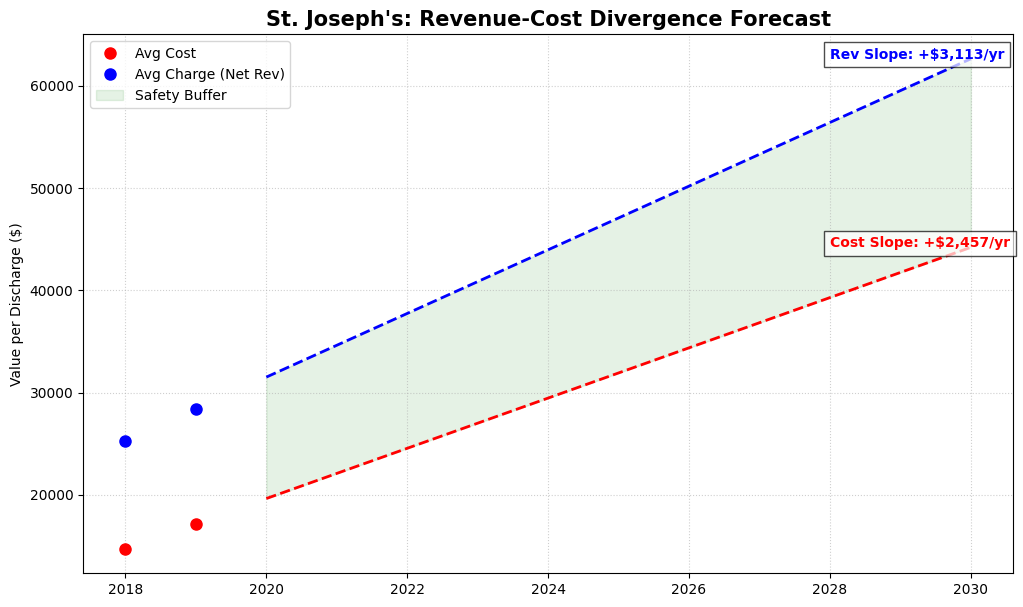

--- St. Joseph's Audit Summary ---
Annual Safety Buffer Expansion: $656.28 per year


In [ ]:
# Isolate St. Joseph's Data
stj = df[df['Facility Name'].str.contains("St. Joseph", na=False)].copy()

# Aggregate Annual Averages
stj_annual = stj.groupby('Year').agg({
    'Total Costs': 'mean',
    'Total Charges': 'mean'
}).reset_index()

# Linear Regression for Projections
# historical data used to project from 2020 to 2030
future_years = np.arange(2020, 2031).reshape(-1, 1)
years_hist = stj_annual['Year'].values.reshape(-1, 1)

# Fit Models
m_cost = LinearRegression().fit(years_hist, stj_annual['Total Costs'])
m_charge = LinearRegression().fit(years_hist, stj_annual['Total Charges'])

# Generate Predictions
cost_p = m_cost.predict(future_years)
charge_p = m_charge.predict(future_years)

# Plotting the results
plt.figure(figsize=(12, 7))

# Historical Points
plt.plot(stj_annual['Year'], stj_annual['Total Costs'], 'ro', markersize=8, label='Avg Cost')
plt.plot(stj_annual['Year'], stj_annual['Total Charges'], 'bo', markersize=8, label='Avg Charge (Net Rev)')

# Trend Lines using the crest-like palette logic (Blue/Red)
plt.plot(future_years, cost_p, 'r--', linewidth=2)
plt.plot(future_years, charge_p, 'b--', linewidth=2)

# Shade the Safety Buffer
# Green area indicates where revenue stays above costs
plt.fill_between(future_years.flatten(), cost_p, charge_p,
                 where=(charge_p >= cost_p), color='green', alpha=0.1, label='Safety Buffer')

# Calculate and Add the Slopes
cost_slope = m_cost.coef_[0]
rev_slope = m_charge.coef_[0]

# Positioning labels at the 2030 mark for readability
plt.text(2028, cost_p[-1], f"Cost Slope: +${cost_slope:,.0f}/yr", color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
plt.text(2028, charge_p[-1], f"Rev Slope: +${rev_slope:,.0f}/yr", color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

# Formatting the visual output
plt.title("St. Joseph's: Revenue-Cost Divergence Forecast", fontsize=15, fontweight='bold')
plt.ylabel("Value per Discharge ($)")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Audit Output
print(f"--- St. Joseph's Audit Summary ---")
print(f"Annual Safety Buffer Expansion: ${rev_slope - cost_slope:,.2f} per year")

Only $656 the CCR / slope difference. Next we compare with the rest of teh hospitals to see them in comparison

## Forecasting for the other hospitals

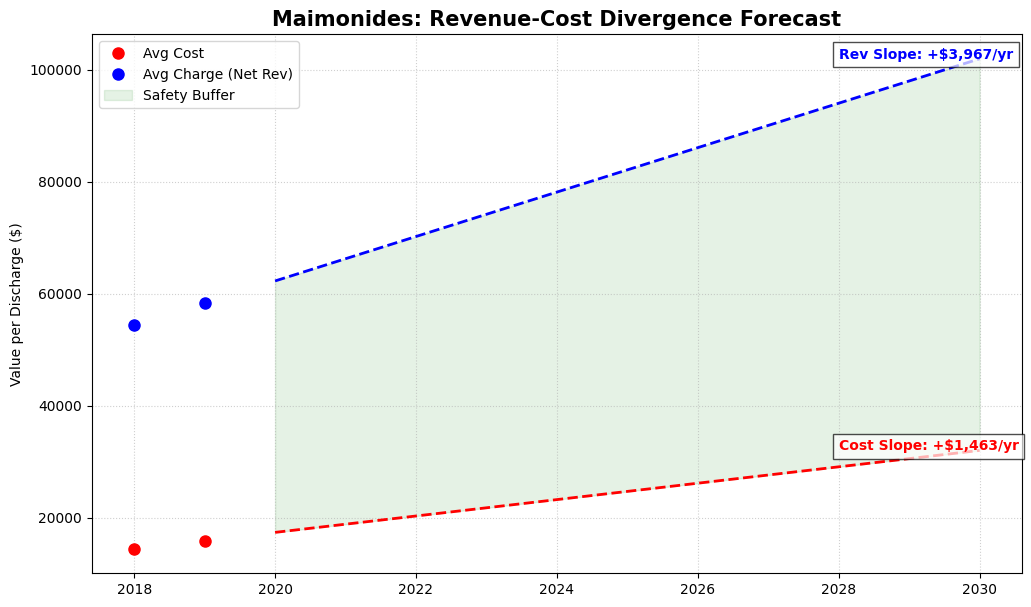

--- Maimonides Audit Summary ---
Annual Revenue Expansion: $2,503.47 per year


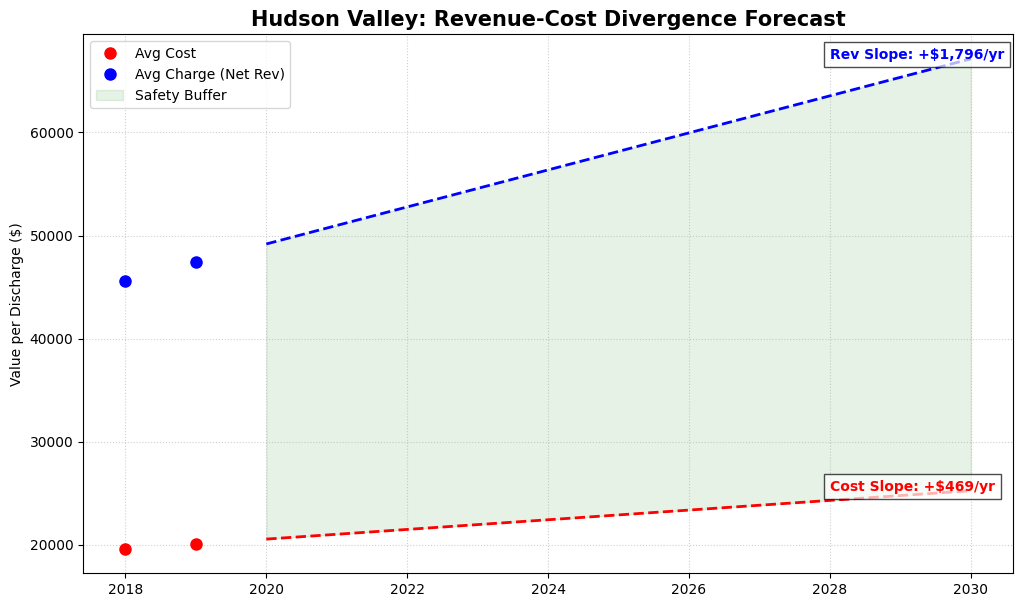

--- Hudson Valley Audit Summary ---
Annual Revenue Expansion: $1,326.76 per year


In [ ]:
target_hospitals = ["Maimonides", "Hudson Valley"]

for hospital in target_hospitals:
    # Filter data for the specific hospital
    h_df = df[df['Facility Name'].str.contains(hospital, na=False)].copy()

    # Aggregate Annual Averages
    h_annual = h_df.groupby('Year').agg({
        'Total Costs': 'mean',
        'Total Charges': 'mean'
    }).reset_index()

    # Linear Regression for Projections (2018 - 2030)
    # Mapping historical trends to a 10-year forecast
    future_years = np.arange(2020, 2031).reshape(-1, 1)
    years_hist = h_annual['Year'].values.reshape(-1, 1)

    m_cost = LinearRegression().fit(years_hist, h_annual['Total Costs'])
    m_charge = LinearRegression().fit(years_hist, h_annual['Total Charges'])

    # Generate Predictions
    cost_p = m_cost.predict(future_years)
    charge_p = m_charge.predict(future_years)

    # Plotting the forecast
    plt.figure(figsize=(12, 7))

    # Historical data points
    plt.plot(h_annual['Year'], h_annual['Total Costs'], 'ro', markersize=8, label='Avg Cost')
    plt.plot(h_annual['Year'], h_annual['Total Charges'], 'bo', markersize=8, label='Avg Charge (Net Rev)')

    # Trend Lines
    plt.plot(future_years, cost_p, 'r--', linewidth=2)
    plt.plot(future_years, charge_p, 'b--', linewidth=2)

    # Fill the Safety Buffer
    # Green shading represents the margin between revenue and cost
    plt.fill_between(future_years.flatten(), cost_p, charge_p,
                     where=(charge_p >= cost_p), color='green', alpha=0.1, label='Safety Buffer')

    # Add the Slopes (Growth Rates)
    cost_slope = m_cost.coef_[0]
    rev_slope = m_charge.coef_[0]

    # Position the text labels at the end of the projection for clarity
    plt.text(2028, cost_p[-1], f"Cost Slope: +${cost_slope:,.0f}/yr", color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    plt.text(2028, charge_p[-1], f"Rev Slope: +${rev_slope:,.0f}/yr", color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

    plt.title(f"{hospital}: Revenue-Cost Divergence Forecast", fontsize=15, fontweight='bold')
    plt.ylabel("Value per Discharge ($)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    # Audit Output
    print(f"--- {hospital} Audit Summary ---")
    print(f"Annual Revenue Expansion: ${rev_slope - cost_slope:,.2f} per year")

We see greater slopes over time for Maimonidis and Hudson Valey. So they are on the safe side. The difference between Charges and Cost have higher values than St Joseph. Look to the follwoing graph


In [ ]:
#gather all results
# List of hospitals to audit
hospitals = ["St. Joseph", "Maimonides", "Hudson Valley"]
audit_results = []

for hospital in hospitals:
    # Filter and aggregate
    h_df = df[df['Facility Name'].str.contains(hospital, na=False)].copy()
    h_annual = h_df.groupby('Year').agg({
        'Total Costs': 'mean',
        'Total Charges': 'mean'
    }).reset_index()

    # Prepare Regression
    X = h_annual['Year'].values.reshape(-1, 1)

    # Calculate Slopes (Increase per Year)
    cost_slope = LinearRegression().fit(X, h_annual['Total Costs']).coef_[0]
    rev_slope = LinearRegression().fit(X, h_annual['Total Charges']).coef_[0]

    # Append to results
    audit_results.append({
        'Hospital': hospital,
        'Cost Increase/yr': cost_slope,
        'Revenue Increase/yr': rev_slope,
        'Margin Expansion/yr': rev_slope - cost_slope
    })

# Create the Final Summary Table
summary_table = pd.DataFrame(audit_results).set_index('Hospital')

# Formatting
styled_summary = summary_table.style.format("${:,.2f}") \
    .background_gradient(cmap='crest', subset=['Margin Expansion/yr']) \
    .set_caption("Table: Annualized Financial Growth and Margin Expansion Analysis")

styled_summary

,Cost Increase/yr,Revenue Increase/yr,Margin Expansion/yr
Hospital,,,
St. Joseph,"$2,456.54","$3,112.82",$656.28
Maimonides,"$1,463.47","$3,966.95","$2,503.47"
Hudson Valley,$469.26,"$1,796.02","$1,326.76"


# Looking at Payer Mix. Hospitals covered by which Payers in %


In [ ]:
# 1. Group by both categories and count discharges
grouped = df.groupby(['Facility Name', 'Payment Type']).size().unstack(fill_value=0)

# 2. Add the Total Volume column
grouped['Total_Discharges'] = grouped.sum(axis=1)

# 3. Create the Percentages (Payer Mix)
# We divide the whole row by the total and multiply by 100
payer_mix = grouped.iloc[:, :-1].div(grouped['Total_Discharges'], axis=0) * 100

# 4. Join them back together
final_audit = pd.concat([grouped[['Total_Discharges']], payer_mix], axis=1)

# Display styled table
final_audit.sort_values('Medicaid', ascending=False).style \
    .background_gradient(cmap='crest', subset=df['Payment Type'].unique()) \
    .format("{:.1f}%", subset=df['Payment Type'].unique()) \
    .format("{:,}", subset=['Total_Discharges'])

Payment Type,Total_Discharges,Medicaid,Medicare,Private,Self-Pay/Other
Facility Name,,,,,
Maimonides,"82,994",51.9%,31.9%,15.0%,1.3%
St. Josephs,"8,010",41.3%,45.4%,9.4%,3.8%
Hudson Valley,"16,678",18.8%,53.9%,25.3%,2.1%


In [ ]:
#  Calculate the raw counts to include 'Total Volume'
payer_counts = pd.crosstab(df['Facility Name'], df['Payment Type'])
payer_counts['Total_Discharges'] = payer_counts.sum(axis=1)

# Calculate the percentages for the core payers
target_payers =  df['Payment Type'].unique().tolist()
payer_mix = pd.crosstab(df['Facility Name'], df['Payment Type'], normalize='index') * 100
payer_mix = payer_mix[target_payers]

# Combine Volume and Percentages
final_table = pd.concat([payer_counts[['Total_Discharges']], payer_mix], axis=1)

# 4. Apply Styling (The Professional Look)
styled_table = final_table.sort_values(by='Medicaid', ascending=False).style \
    .background_gradient(cmap='crest', subset=target_payers) \
    .format("{:.1f}%", subset=target_payers) \
    .format("{:,}", subset=['Total_Discharges']) \
    .set_caption("Table 1: Institutional Payer Mix & Volume Audit (2018-2019)") \
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '12pt'), ('background-color', '#f4f4f4')]}])

#To view in table format
styled_table

Payment Type,Total_Discharges,Medicaid,Medicare,Private,Self-Pay/Other
Facility Name,,,,,
Maimonides,"82,994",51.9%,31.9%,15.0%,1.3%
St. Josephs,"8,010",41.3%,45.4%,9.4%,3.8%
Hudson Valley,"16,678",18.8%,53.9%,25.3%,2.1%


Maimonides and St. Joseph are mainly Federal and State  
Hudson has a big precentage of Private. Possibly bigger CCR --> Investigate

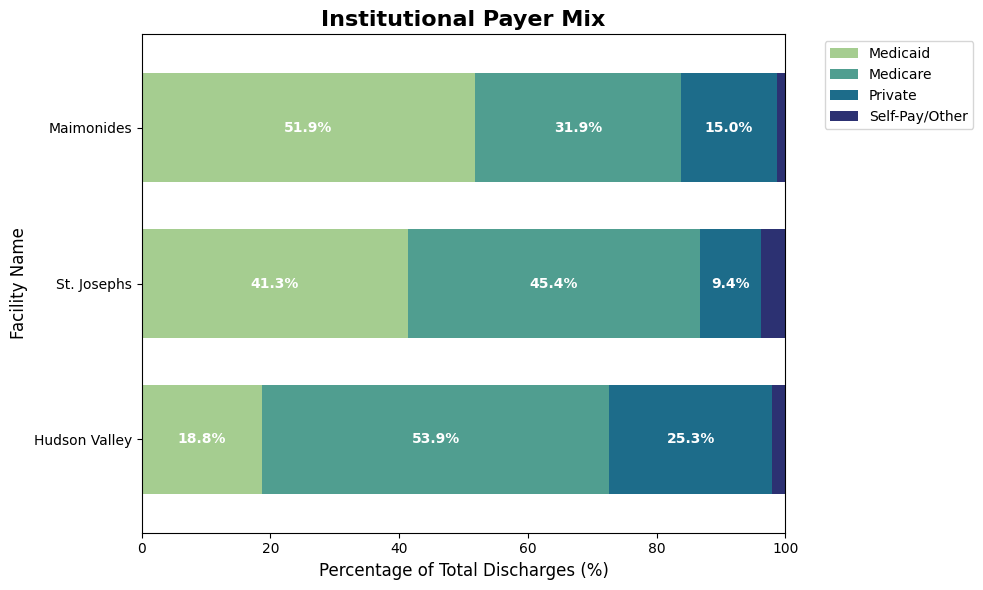

In [ ]:
# Show Payer Mix in stacked bar %
plot_data = payer_mix.sort_values(by='Medicaid', ascending=True)

# 2. Create the Stacked Bar Chart
ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    colormap='crest',
    width=0.7
)

# 3. Add Percentage Labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 5: # Only label segments larger than 5% for clarity
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{width:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# 4. Formatting
plt.title("Institutional Payer Mix", fontsize=16, fontweight='bold')
plt.xlabel("Percentage of Total Discharges (%)", fontsize=12)
plt.ylabel("Facility Name", fontsize=12)
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left') #title="Payment Type",
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

**Insight**  
***Maimonides*** is a FEDERAL Driven Hospital (limited Income) --> Safety net, Medicaid and Medicare mostly.   
**St Joseph** as well. with the lowest percentage in Private  (limited income and >65)  
**Hudson Valley** mostly on Medicare : > 65 years old and special disabilities. Most commercial with 25% with Private insurance. "Commercial Mix," allowing them to maintain a more standardized, profitable markup across all patients

## Payer Mix for Hudson Valey

And we see that Hundson Valey uses a bit larger CRR compared to the rest of teh Insurances for SELFPAY !!!!

,Min_CCR,Median_CCR,Max_CCR
Payment Type,,,
Self-Pay/Other,$1.11,$2.53,$9.01
Private,$0.80,$2.41,$9.25
Medicare,$1.18,$2.39,$19.41
Medicaid,$0.80,$1.99,$9.16


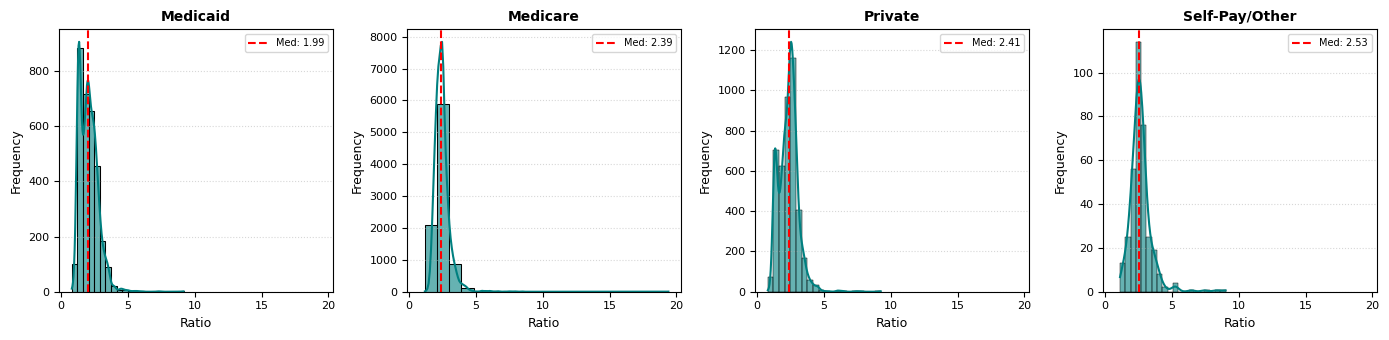

In [ ]:
# Isolate Hudson Valley data for the institutional audit
hudson_df = df[df['Facility Name'].str.contains("Hudson Valley", na=False)].copy()

# Calculate the minimum, maximum, and median CCR values for each Payment Type
# The median is often more reliable than the mean for skewed healthcare data
hudson_stats = hudson_df.groupby('Payment Type')['CCR'].agg(
    Min_CCR='min',
    Median_CCR='median',
    Max_CCR='max'
).sort_values(by='Median_CCR', ascending=False)

# Apply professional styling to the statistics table
# This highlights the central tendency and the range of charges
styled_hudson_stats = hudson_stats.style.format("${:,.2f}") \
    .background_gradient(cmap='YlGnBu', subset=['Median_CCR']) \
    .set_caption("Hudson Valley Audit: CCR Range and Median by Payment Type")

display(styled_hudson_stats)

# Create a small, horizontal grid of histograms to visualize the data density
# We include a vertical line to pinpoint the median in each distribution
payment_categories = ['Medicaid', 'Medicare', 'Private', 'Self-Pay/Other']
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharex=True)

for i, p_type in enumerate(payment_categories):
    subset = hudson_df[hudson_df['Payment Type'] == p_type]

    # Calculate the median for the specific category to plot the line
    p_median = subset['CCR'].median()

    # Plot the histogram with KDE
    sns.histplot(subset['CCR'], bins=20, kde=True, ax=axes[i], color='teal', alpha=0.6)

    # Add the vertical median line for visual reference
    axes[i].axvline(p_median, color='red', linestyle='--', linewidth=1.5, label=f'Med: {p_median:.2f}')

    # Clean, minimalist labels for the thesis dashboard
    axes[i].set_title(p_type, fontweight='bold', fontsize=10)
    axes[i].set_xlabel("Ratio", fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)
    axes[i].tick_params(labelsize=8)
    axes[i].legend(fontsize=7)
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

The are very close, so not definite conclusion. Ohter than that the LOS is smaller than St. Joseph and the CCR larger

# Looking at Volume

In [ ]:
# Create a Volume Table (Counts per Year per Facility)
volume_table = df.groupby(['Facility Name', 'Year']).size().unstack(fill_value=0)

# Calculate the Percentage Change (%)
volume_table['% Change'] = ((volume_table[2019] - volume_table[2018]) / volume_table[2018]) * 100

# Apply Styling
styled_volume = volume_table.style.format("{:,.0f}", subset=[2018, 2019]) \
    .format("{:+.2f}%", subset=['% Change']) \
    .background_gradient(cmap='crest', subset=['% Change'])

styled_volume

Year,2018,2019,% Change
Facility Name,,,
Hudson Valley,"8,421","8,257",-1.95%
Maimonides,"41,878","41,116",-1.82%
St. Josephs,"4,007","4,003",-0.10%


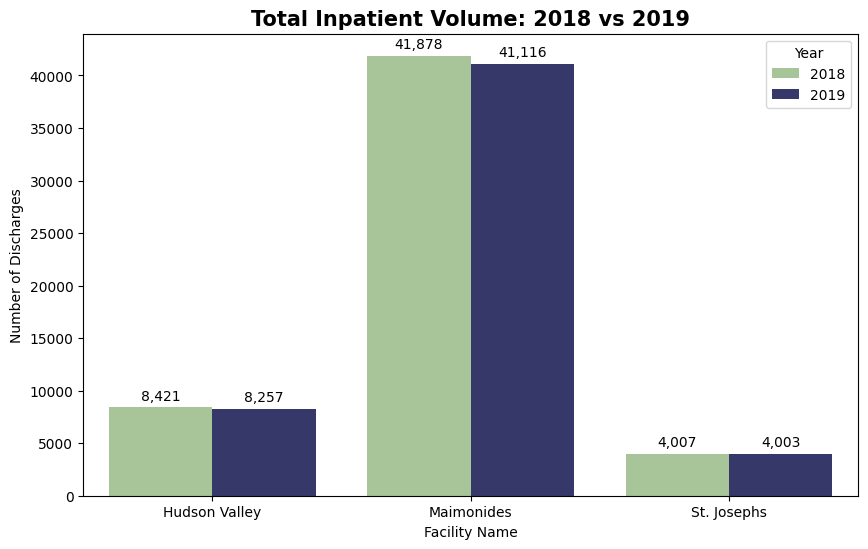

In [ ]:
# Create a melted version for side-by-side bars
volume_melted = volume_table[[2018, 2019]].reset_index().melt(id_vars='Facility Name', var_name='Year', value_name='Inpatients')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=volume_melted, x='Facility Name', y='Inpatients', hue='Year', palette='crest')

# Add labels to show the scale difference
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title("Total Inpatient Volume: 2018 vs 2019", fontsize=15, fontweight='bold')
plt.ylabel("Number of Discharges")
plt.show()

# Looking at Cost Per Day - Increasing Costs for 2 last years

In [ ]:
# Group by Facility and Year
efficiency_audit = df.groupby(['Facility Name', 'Year']).agg(
    Avg_LOS=('Length of Stay', 'mean'),
    Avg_Cost_Per_Patient=('Total Costs', 'mean'),
    Avg_Cost_Per_Day=('Cost per Day', 'mean')
).unstack()

# Calculate % Change for the "Efficiency Pincer"
efficiency_audit['LOS_%_Change'] = ((efficiency_audit['Avg_LOS'][2019] - efficiency_audit['Avg_LOS'][2018]) / efficiency_audit['Avg_LOS'][2018]) * 100
efficiency_audit['Day_Cost_%_Change'] = ((efficiency_audit['Avg_Cost_Per_Day'][2019] - efficiency_audit['Avg_Cost_Per_Day'][2018]) / efficiency_audit['Avg_Cost_Per_Day'][2018]) * 100


styled_efficiency = efficiency_audit.style.format("{:.2f} Days", subset=[('Avg_LOS', 2018), ('Avg_LOS', 2019)]) \
    .format("${:,.0f}", subset=[('Avg_Cost_Per_Day', 2018), ('Avg_Cost_Per_Day', 2019)]) \
    .format("{:+.2f}%", subset=['LOS_%_Change', 'Day_Cost_%_Change']) \
    .background_gradient(cmap='crest', subset=['Day_Cost_%_Change'])

styled_efficiency

St Joseph shows the greater increase in cost per day.  And also they achieved the most %LOS becoming smaller

## By Hospital LOS vs AvgCost per Day


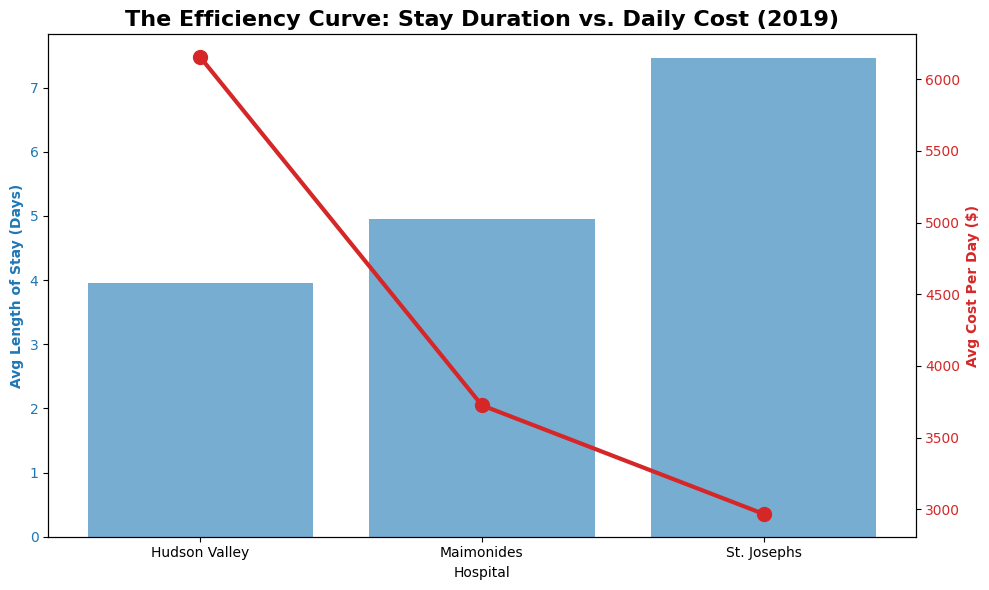

In [ ]:
# Prepare the data
facilities = efficiency_audit.index
los_2019 = efficiency_audit[('Avg_LOS', 2019)]
cost_day_2019 = efficiency_audit[('Avg_Cost_Per_Day', 2019)]

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot Avg LOS as Bars
color = 'tab:blue'
ax1.set_xlabel('Hospital')
ax1.set_ylabel('Avg Length of Stay (Days)', color=color, fontweight='bold')
ax1.bar(facilities, los_2019, color=color, alpha=0.6, label='Length of Stay')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second Y-axis for Cost Per Day
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Cost Per Day ($)', color=color, fontweight='bold')
ax2.plot(facilities, cost_day_2019, color=color, marker='o', linewidth=3, markersize=10, label='Cost Per Day')
ax2.tick_params(axis='y', labelcolor=color)

# Formatting
plt.title("The Efficiency Curve: Stay Duration vs. Daily Cost (2019)", fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

In [ ]:
#This will not help St. Joseph as they are having large LOS (inversely moving with the Total Cost in correlation) and having the smallest AVG Cost per Day !

## By payment Method LOS vs AvgCost per Day

In [ ]:
df.columns

Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs',
       'Charge per Day', 'Cost per Day', 'CCR', 'Markup Amount', 'Markup %',
       'Severity_Rank', 'Mortality_Rank', 'Age_Rank', 'Ratio', 'Kmeans'],
      dtype='object')

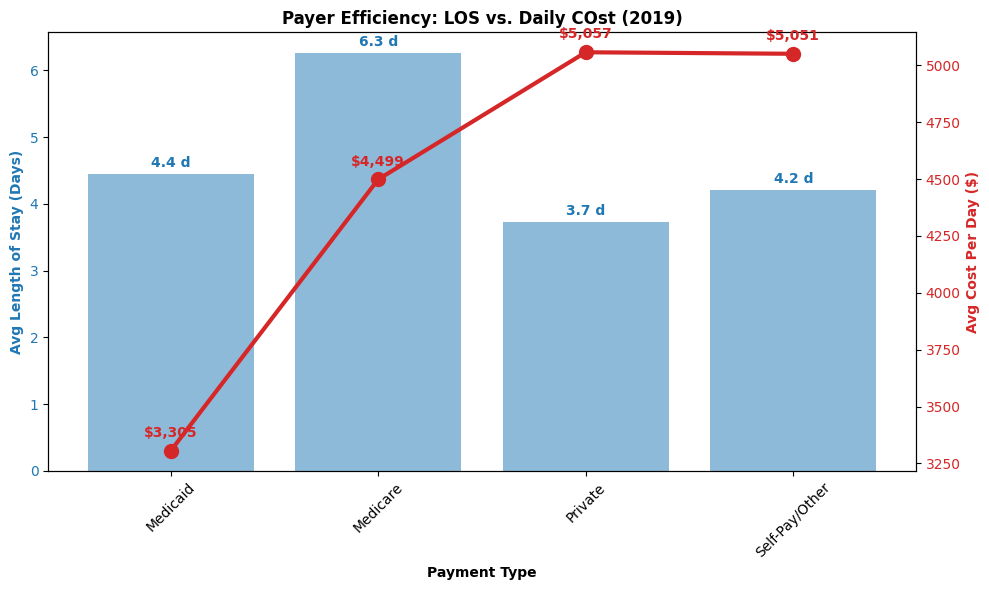

In [ ]:
# Create the payer_efficiency table
payer_efficiency = df.groupby(['Payment Type', 'Year']).agg(
    Avg_LOS=('Length of Stay', 'mean'),
    Avg_Cost_Per_Day=('Cost per Day', 'mean')
).unstack()

# index (Payment Type)
# This must be in the same cell as the plotting code
payers = payer_efficiency.index
los_2019 = payer_efficiency[('Avg_LOS', 2019)]
cost_day_2019 = payer_efficiency[('Avg_Cost_Per_Day', 2019)]

# Create the Figure and First Axis
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot Avg LOS as Bars (Primary Y-Axis)
color_bars = 'tab:blue'
ax1.set_xlabel('Payment Type', fontsize=10, fontweight='bold')
ax1.set_ylabel('Avg Length of Stay (Days)', color=color_bars, fontsize=10, fontweight='bold')
bars = ax1.bar(payers, los_2019, color=color_bars, alpha=0.5) # Removed label='...' to avoid TypeError
ax1.tick_params(axis='y', labelcolor=color_bars)
plt.xticks(rotation=45)

# Add numeric labels to the bars
ax1.bar_label(bars, fmt='%.1f d', padding=3, color=color_bars, fontweight='bold')

# Create the Second Axis (The 'twin' axis)
ax2 = ax1.twinx()
color_line = 'tab:red'
ax2.set_ylabel('Avg Cost Per Day ($)', color=color_line, fontsize=10, fontweight='bold')

# Plot Cost Per Day as a Line (Secondary Y-Axis)
ax2.plot(payers, cost_day_2019, color=color_line, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color_line)

# Add numeric labels to the line points
for i, val in enumerate(cost_day_2019):
    ax2.annotate(f'${val:,.0f}', (i, val), # Using 'i' for index position
                 textcoords="offset points", xytext=(0,10), ha='center',
                 color=color_line, fontweight='bold')
plt.title("Payer Efficiency: LOS vs. Daily COst (2019)", fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

Small length of stay but high average cost per day for the Private and Self-Pay. The most social dependent Payer (Medicaid) has the smallest Avg Cost per Day. Need to see the severities per

# Looking at Avg Cost Per Day by Payment Type changes in 2018 - 2019

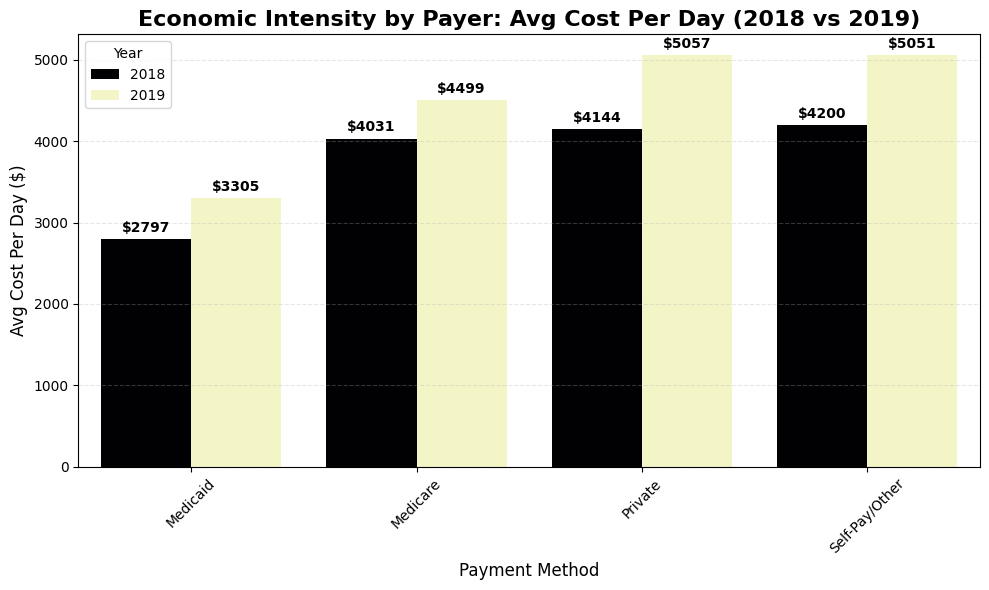

In [ ]:
# 1. Prepare data from payer_efficiency table
# Using underscores consistently to avoid the 'Column Not Found' error
payer_cost_melted = payer_efficiency['Avg_Cost_Per_Day'].reset_index().melt(
    id_vars='Payment Type',
    var_name='Year',
    value_name='Avg_Cost_Per_Day' # Matching this name exactly
)

plt.figure(figsize=(10, 6))

# 2. Create the plot using the exact column name 'Avg_Cost_Per_Day'
ax = sns.barplot(
    data=payer_cost_melted,
    x='Payment Type',
    y='Avg_Cost_Per_Day', # Fixed the name here
    hue='Year',
    palette='magma'
)

# 3. Add data labels for the "Audit" look
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')

# 4. Final Formatting
plt.title("Economic Intensity by Payer: Avg Cost Per Day (2018 vs 2019)", fontsize=16, fontweight='bold')
plt.ylabel("Avg Cost Per Day ($)", fontsize=12)
plt.xlabel("Payment Method", fontsize=12)
plt.xticks(rotation=45) # Helps if payment names are long
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Looking at LOS per hospital

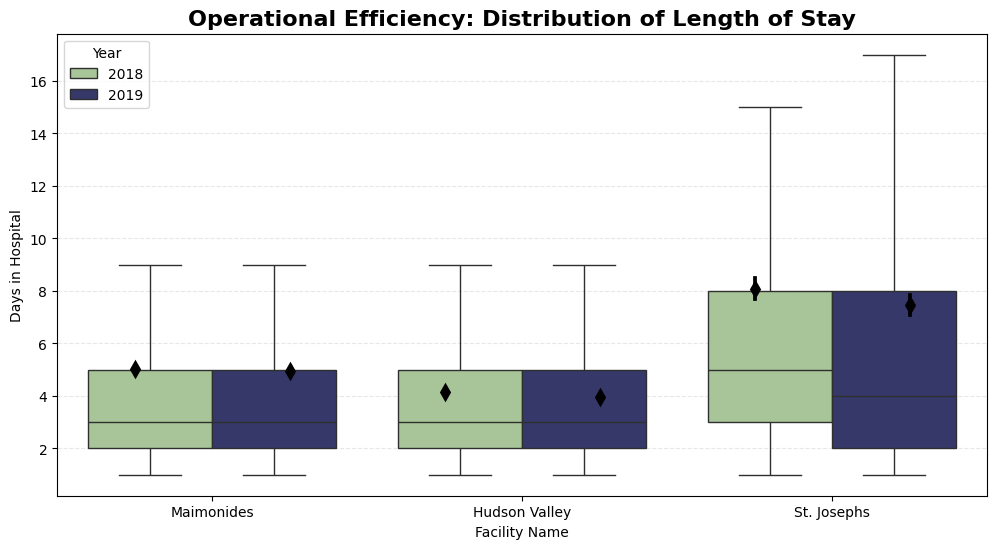

In [ ]:
plt.figure(figsize=(12, 6))

# 1. Main Boxplot
ax = sns.boxplot(
    data=df,
    x='Facility Name',
    y='Length of Stay',
    hue='Year',
    palette='crest',
    showfliers=False
)

# 2. Add Mean Markers (Modern Syntax)
# We use palette='dark:black' to make the mean markers black across all years
# We use linestyle='none' instead of join=False
sns.pointplot(
    data=df,
    x='Facility Name',
    y='Length of Stay',
    hue='Year',
    dodge=0.5,
    markers='d',
    linestyle='none',
    palette=['black', 'black'],
    ax=ax
)

# 3. Formatting
plt.title("Operational Efficiency: Distribution of Length of Stay", fontsize=16, fontweight='bold')
plt.ylabel("Days in Hospital")
plt.xlabel("Facility Name")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove duplicate legend entries if necessary
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Year')

plt.show()

**Insights**  
***Hudson Valey*** has managed to shorten the average LOS in 2019.  
With a -0.10 correlation with Cost per day and the Markup%, it means that the lenghier, the less  this contributes to their profit.  
In ***St. Josseph*** the increase in Mean values of LOS means that St.Joseph has more patents staying longer than usual and it cannot afford this. Also in 2019, the median drops and this is a good sign. But still too many long stays.  
**Maimonidis can handle** the slightly increased mean value. A bit lenghtier stays

In [ ]:
# Ensure the Payer Efficiency Table is created using the correct column name
# We use brackets ['Cost per Day'] to handle the spaces in the name
payer_efficiency = df.groupby(['Payment Type', 'Year']).agg(
    Avg_LOS=('Length of Stay', 'mean'),
    Avg_Cost_Per_Patient=('Total Costs', 'mean'),
    Avg_Cost_Per_Day=('Cost per Day', 'mean')
).unstack()

# Calculate % Change to identify which Payer is becoming more "Expensive"
# This compares 2019 vs 2018 data within the multi-index columns
payer_efficiency['LOS_%_Change'] = ((payer_efficiency[('Avg_LOS', 2019)] - payer_efficiency[('Avg_LOS', 2018)]) / payer_efficiency[('Avg_LOS', 2018)]) * 100
payer_efficiency['Day_Cost_%_Change'] = ((payer_efficiency[('Avg_Cost_Per_Day', 2019)] - payer_efficiency[('Avg_Cost_Per_Day', 2018)]) / payer_efficiency[('Avg_Cost_Per_Day', 2018)]) * 100

# Using specific tuples to reference the MultiIndex columns correctly for formatting
styled_payer_audit = payer_efficiency.style.format("{:.2f} Days", subset=[('Avg_LOS', 2018), ('Avg_LOS', 2019)]) \
    .format("${:,.0f}", subset=[('Avg_Cost_Per_Day', 2018), ('Avg_Cost_Per_Day', 2019)]) \
    .format("${:,.0f}", subset=[('Avg_Cost_Per_Patient', 2018), ('Avg_Cost_Per_Patient', 2019)]) \
    .format("{:+.2f}%", subset=['LOS_%_Change', 'Day_Cost_%_Change']) \
    .background_gradient(cmap='crest', subset=['Day_Cost_%_Change']) \
    .set_caption("Table: Efficiency and Intensity Audit by Payer Type (2018-2019)")

# Display the styled table
styled_payer_audit

**Insight**
###  Financial Summary (2018-2019)**

| Hospital | Financial Characterization | Volume Profile | Margin Profile (Slope) | The "Bottom Line" |
| :--- | :--- | :--- | :--- | :--- |
| **Hudson Valley** |  **Efficient Premium** | Largest Drop in Volume (-1.95%) | High / Optimized | Large private contribution and Medicare, hence large DayCost increase, but steady 2.3x slope for all trading methods. Strongest financial cushion. |
| **Maimonides** |  **Resilient Safety-Net** | Managed Volume Drop (-1.82%) | Tiered / Strategic | Massive volume and "3-Line" billing offsets with largest Medicaid exposure. Paying even a lot over cost |
| **St. Joseph's** |  **Vulnerable Pillar** | No Volume Change (-0.10%) | **Critical / Lowest** | Dependent on State / Federal with not so good apyment mix strategies. Low margine |

---

### ** Summary**
The data confirms a **correlation between institutional scale and pricing power.** While Hudson Valley can sustain volume losses through high-margin optimization, **St. Joseph's** "compressed" pricing model leaves it with no defensive buffer against the rising unit costs (Cost per Day) identified in the efficiency audit. Maimonides represents a hybrid "Safety Net" model that survives through sheer volume and sophisticated, tiered revenue management.

## Analyzing Maimonides

In [ ]:
df.groupby('Facility Name')['Payment Type'].value_counts()

Facility Name  Payment Type  
Hudson Valley  Medicare           8988
               Private            4214
               Medicaid           3130
               Self-Pay/Other      346
Maimonides     Medicaid          43036
               Medicare          26481
               Private           12426
               Self-Pay/Other     1051
St. Josephs    Medicare           3639
               Medicaid           3309
               Private             756
               Self-Pay/Other      306
Name: count, dtype: int64

### LOS vs Total Charges

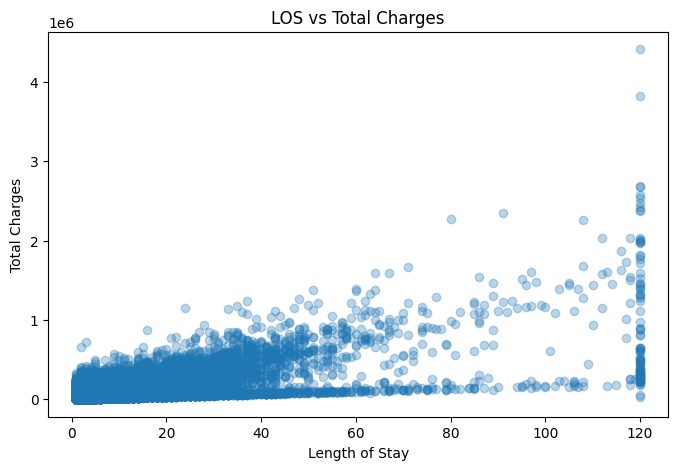

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Length of Stay"], df["Total Charges"], alpha=0.3)

plt.xlabel("Length of Stay")
plt.ylabel("Total Charges")
plt.title("LOS vs Total Charges")

plt.show()

***Insight**
Longer stay, larger charges.
But this is not the only driver for Charges (i.e severity, type of illness, procedure)
120 CAP is due to 120+ in the dataset


# Looking at Severity

In [ ]:
df.columns


Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs',
       'Charge per Day', 'Cost per Day', 'CCR', 'Markup Amount', 'Markup %',
       'Severity_Rank', 'Mortality_Rank', 'Age_Rank', 'Ratio', 'Kmeans'],
      dtype='object')

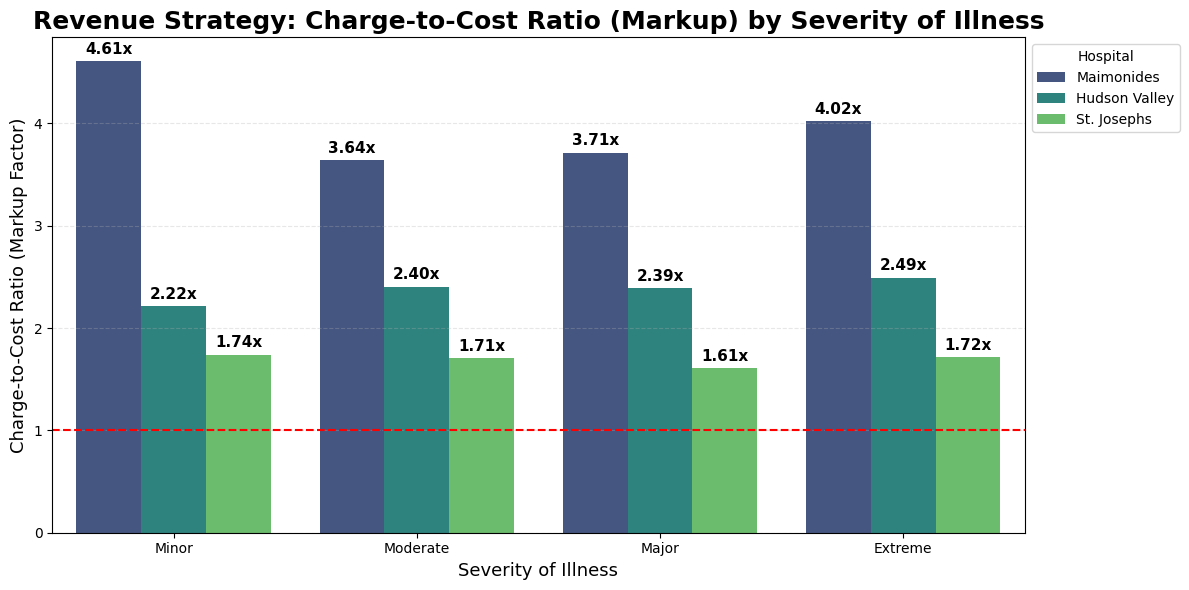

In [ ]:

severity_order = ['Minor', 'Moderate', 'Major', 'Extreme']

# 3Create the Visualization
plt.figure(figsize=(12, 6))

# We capture the axes object as 'ax' so we can add labels to it
ax = sns.barplot(
    data=df,
    x='Severity of Illness',
    y='CCR',
    hue='Facility Name',
    order=severity_order,
    palette='viridis',
    errorbar=None
)

# Add the numbers on top of the bars
# This loop iterates through the bars and places the numeric label
for container in ax.containers:
    ax.bar_label(container, fmt='%.2fx', padding=3, fontsize=11, fontweight='bold')

# 5. Formatting for the Report
plt.title("Revenue Strategy: Charge-to-Cost Ratio (Markup) by Severity of Illness", fontsize=18, fontweight='bold')
plt.ylabel("Charge-to-Cost Ratio (Markup Factor)", fontsize=13)
plt.xlabel("Severity of Illness", fontsize=13)
plt.legend(title="Hospital", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add a horizontal line at 1.0 (The "At-Cost" line)
plt.axhline(1.0, color='red', linestyle='--', label='Breakeven (1.0x)')

plt.tight_layout()
plt.show()

**Insights**  
St Joseph is very stable across all severities of illness. It charges about 1.8x the cost  
Hudson Valey the same, charges 2.3x the cost  
Maimonidis has a lot of buffer 4x the charges  Especially for Minor and Extreme

### **Charge to Cost Disparity**

The labeled **Charge-to-Cost Ratio** chart provides definitive proof of institutional financial vulnerability:

1. **Strategic Scaling:** Maimonides exhibits a 'Complexity-Driven' pricing model, using  **3.13x to 3.42x** markup as severity increases. This allows the facility to cross-subsidize its heavy Medicaid burden.  
***Very large CCR for the Minor cases***
2. **The St. Joseph's Fragility:** St. Joseph's consistently maintains the lowest markup factors in the cohort, failing to reach even a **2.0x** ratio in any category.
3. **The Conclusion:** Operating at a **~1.8x** markup in a high-inflation healthcare environment leaves St. Joseph's with no 'Margin of Safety.' While Hudson Valley is protected by a stable 2.3x premium model, St. Joseph's is structurally exposed to any increase in operational 'Cost per Day.'

Average cost per hospital

In [ ]:
df.groupby("Facility Name")["Total Charges"].mean()

,Total Charges
Facility Name,
Hudson Valley,46483.712045
Maimonides,56286.925778
St. Josephs,26847.041395


In [ ]:
df.groupby("Facility Name")["Total Charges"].count()

,Total Charges
Facility Name,
Hudson Valley,16678
Maimonides,82994
St. Josephs,8010


Average Cost by Severity

In [ ]:
order = ["Minor", "Moderate", "Major", "Extreme"]

result = df.groupby("Severity of Illness")["Total Charges"].mean()

result = result.reindex(order)

result

,Total Charges
Severity of Illness,
Minor,25623.050022
Moderate,42006.692461
Major,67658.492493
Extreme,163907.040751


Emergency Rage

In [ ]:
df["ED Indicator"].value_counts(normalize=True)

,proportion
ED Indicator,
True,0.536821
False,0.463179


# Find the Medicaid Diseases and Severities.

Mix of Severities and diseases in Medicaid

In [ ]:
# Filter for Medicaid only
medicaid_df = df[df['Payment Type'] == 'Medicaid'].copy()

# Create the Cross-Tabulation (Illness vs. Severity)
# This shows the "Mix" for the top 15 most common diseases
top_diseases = medicaid_df['Diagnosis'].value_counts().nlargest(15).index
clinical_mix = pd.crosstab(
    medicaid_df[medicaid_df['Diagnosis'].isin(top_diseases)]['Diagnosis'],
    medicaid_df['Severity of Illness']
)

# Total_patients column and sort by volume
clinical_mix['Total_Patients'] = clinical_mix.sum(axis=1)
clinical_mix = clinical_mix.sort_values(by='Total_Patients', ascending=False)

print("--- Medicaid Clinical Mix: Top 15 Diseases by Severity ---")
print(clinical_mix)

--- Medicaid Clinical Mix: Top 15 Diseases by Severity ---
Severity of Illness                                 Extreme  Major  Minor  \
Diagnosis                                                                   
NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEONA...        0    287  10697   
VAGINAL DELIVERY                                          9    224   7457   
CESAREAN DELIVERY                                        24    277   1844   
SCHIZOPHRENIA                                             3     25    362   
SEPTICEMIA & DISSEMINATED INFECTIONS                    437    361     94   
BIPOLAR DISORDERS                                         1      2    195   
RESPIRATORY FAILURE                                      29    239      0   
BRONCHIOLITIS & RSV PNEUMONIA                            36    363     34   
ALCOHOL ABUSE & DEPENDENCE                               21     90    106   
OTHER ANTEPARTUM DIAGNOSES                               10    111    136   
NEONATE BWT 2000-

# Find Severities and Diseases in St Joseph

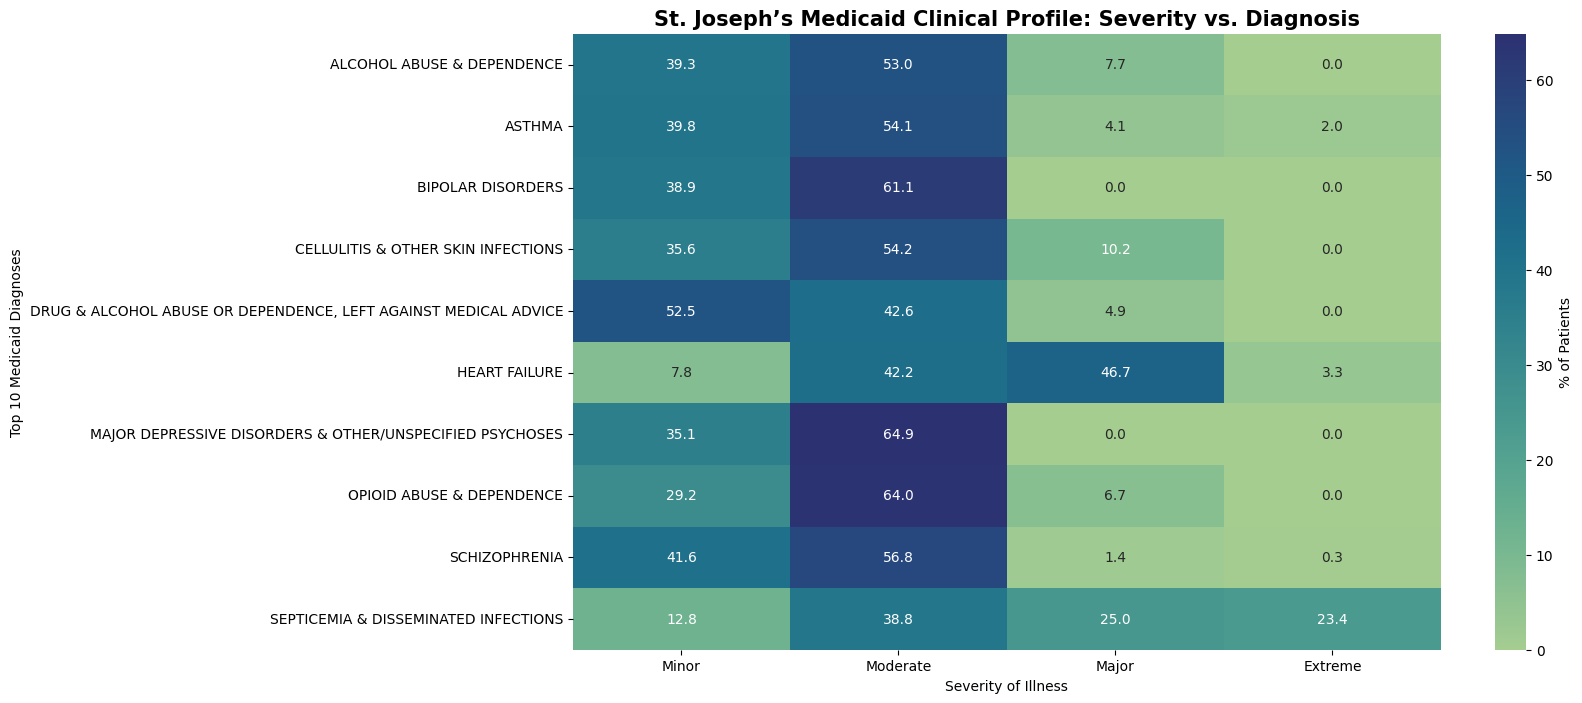

--- St. Joseph's Financial Burden by Severity of Illness ---
                     Total Costs  Length of Stay
Severity of Illness                             
Minor                   15133.20           11.98
Moderate                16342.80           12.47
Major                   19808.44            8.97
Extreme                 39556.44           12.38


In [ ]:
# Filter for St. Joseph's Medicaid only
stj_medicaid = df[(df['Payment Type'] == 'Medicaid') &
                  (df['Facility Name'].str.contains("St. Joseph", na=False))].copy()

# Identify their Top 10 Diagnoses by volume
stj_top_10 = stj_medicaid['Diagnosis'].value_counts().nlargest(10).index
stj_subset = stj_medicaid[stj_medicaid['Diagnosis'].isin(stj_top_10)].copy()

# Set the logical order for Severity
severity_order = ['Minor', 'Moderate', 'Major', 'Extreme']

# Convert the column to a Categorical type with the specific clinical order
stj_subset['Severity of Illness'] = pd.Categorical(
    stj_subset['Severity of Illness'],
    categories=severity_order,
    ordered=True
)

# Create the Mix (Cross-tab)
# Note: Categorical type above ensures the X-axis is ordered Minor -> Extreme
stj_mix = pd.crosstab(
    stj_subset['Diagnosis'],
    stj_subset['Severity of Illness'],
    normalize='index'
) * 100

# Severity Profile Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(stj_mix, annot=True, fmt=".1f", cmap="crest", cbar_kws={'label': '% of Patients'})

plt.title("St. Joseph’s Medicaid Clinical Profile: Severity vs. Diagnosis", fontsize=15, fontweight='bold')
plt.xlabel("Severity of Illness")
plt.ylabel("Top 10 Medicaid Diagnoses")
plt.show()

# Financial Audit of these Severities
# observed=False ensures the logical order is strictly maintained in the output
stj_fin = stj_subset.groupby('Severity of Illness', observed=False).agg({
    'Total Costs': 'mean',
    'Length of Stay': 'mean'
}).round(2)

print("--- St. Joseph's Financial Burden by Severity of Illness ---")
print(stj_fin)


St Joseph seems to have SCHIZOPHRENIA --> which is a LOSS LEADER  
ST Joseph seems not to have NEONATAL --> CASH COW.  
Aslo the fact that CCR is always around 1.7 does not help with the LOS aroung 10!

# Find if St. Joseph has anything in Group 2, the cash cows

In [ ]:
# Isolate St. Joseph's Medicaid
stj_medicaid = df[(df['Facility Name'].str.contains("St. Joseph")) & (df['Payment Type'] == 'Medicaid')].copy()

# Look for "Group 2" behavior (High Ratio > 5.0)
stj_group2 = stj_medicaid[stj_medicaid['CCR'] > 5.0]

print(f"Total St. Joseph's Medicaid Patients: {len(stj_medicaid)}")
print(f"Potential Group 2 Patients: {len(stj_group2)}")
print(f"Percentage: {(len(stj_group2)/len(stj_medicaid))*100:.2f}%")

# What illnesses are in this group at St. Joseph's?
print("\nTop Diagnoses in St. Joseph's High-Ratio Segment:")
print(stj_group2['Diagnosis'].value_counts().head(5))

Total St. Joseph's Medicaid Patients: 3309
Potential Group 2 Patients: 0
Percentage: 0.00%

Top Diagnoses in St. Joseph's High-Ratio Segment:
Series([], Name: count, dtype: int64)


# Extract final file

In [ ]:
df.columns

Index(['Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Admission Type', 'Patient Disposition',
       'Year', 'Diagnosis', 'Severity of Illness', 'Risk of Mortality',
       'Payment Type', 'ED Indicator', 'Total Charges', 'Total Costs',
       'Charge per Day', 'Cost per Day', 'CCR', 'Markup Amount', 'Markup %',
       'Severity_Rank', 'Mortality_Rank', 'Age_Rank', 'Ratio', 'Kmeans'],
      dtype='object')

In [ ]:
df.head()

,Hospital County,Facility Name,Age Group,Gender,Race,Ethnicity,Length of Stay,Admission Type,Patient Disposition,Year,Diagnosis,Severity of Illness,Risk of Mortality,Payment Type,ED Indicator,Total Charges,Total Costs,Charge per Day,Cost per Day,CCR,Markup Amount,Markup %,Severity_Rank,Mortality_Rank,Age_Rank,Ratio,Kmeans
0,Kings,Maimonides,0 to 17,F,Other Race,Not Span/Hispanic,1,Emergency,Home or Self Care,2018,OTHER PNEUMONIA,Moderate,Minor,Medicaid,False,7983.00,3447.96,7983.000000,3447.9600,2.315282,4535.04,131.528208,2,1,1,2.315282,1
1,Kings,Maimonides,70 or Older,M,Other Race,Not Span/Hispanic,4,Emergency,Home or Self Care,2018,MALE REPRODUCTIVE SYSTEM DIAGNOSES EXCEPT MALI...,Major,Major,Medicare,False,23752.02,6475.87,5938.005000,1618.9675,3.667773,17276.15,266.777282,3,3,5,3.667773,0
2,Kings,Maimonides,0 to 17,M,Other Race,Not Span/Hispanic,15,Newborn,Home or Self Care,2018,NEONATE BWT 1500-1999G W OR W/O OTHER SIGNIFIC...,Moderate,Minor,Private,False,175527.01,24953.85,11701.800667,1663.5900,7.034065,150573.16,603.406528,2,1,1,7.034065,2
3,Kings,Maimonides,0 to 17,M,White,Not Span/Hispanic,2,Newborn,Home or Self Care,2018,"NEONATE BIRTHWT >2499G, NORMAL NEWBORN OR NEON...",Minor,Minor,Medicaid,False,6002.00,957.17,3001.000000,478.5850,6.270568,5044.83,527.056845,1,1,1,6.270568,2
4,Kings,Maimonides,18 to 29,F,Black/African American,Not Span/Hispanic,7,Urgent,Home or Self Care,2018,CESAREAN DELIVERY,Major,Moderate,Medicaid,True,93066.13,26080.60,13295.161429,3725.8000,3.568404,66985.53,256.840448,3,2,2,3.568404,0


In [ ]:
#save file to csv
#df.to_csv("final_hospital_discharges1819.csv", index=False)